In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from vivarium import Artifact, InteractiveContext
import pandas as pd, numpy as np, os

In [2]:
!whoami
!date

zmbc
Tue Nov  4 04:49:38 PM PST 2025


# V&V neonatal mortality in an interactive simulation

General approach:
* Check quantities subject to stochastic uncertainty both visually and with a statistical test
* Single draw, location, and scenario (baseline)
* Only test relative to artifact, because GBD shared functions can't be directly used in the sim environment -- **this notebook will not find issues in artifact creation**

Note: ran this off the model 19.1.1 branch.

In [3]:
%pip list | grep vivarium

vivarium                  3.5.6
vivarium_build_utils      2.0.12
vivarium_cluster_tools    2.1.22
vivarium_dependencies     1.0.1
vivarium_gates_mncnh      0.1.dev320+g54255129e.d20251024 /mnt/share/homes/zmbc/src/vivarium_gates_mncnh
vivarium_public_health    4.3.12
vivarium_testing_utils    0.2.5
Note: you may need to restart the kernel to use updated packages.


In [4]:
# TODO
%pip freeze | grep vivarium

ERROR: Error [Errno 2] No such file or directory: 'git' while executing command git config --get-regexp 'remote\..*\.url'
vivarium==3.5.6
vivarium_build_utils==2.0.12
vivarium_cluster_tools==2.1.22
vivarium_dependencies==1.0.1
-e /mnt/share/homes/zmbc/src/vivarium_gates_mncnh
vivarium_public_health==4.3.12
vivarium_testing_utils==0.2.5
Note: you may need to restart the kernel to use updated packages.


In [5]:
# Workaround for above issues with git not being installed in the Jupyter image
! cat /mnt/share/homes/zmbc/src/vivarium_gates_mncnh/.git/HEAD

ref: refs/heads/epic/gbd_2023_updates


In [6]:
! cat /mnt/share/homes/zmbc/src/vivarium_gates_mncnh/.git/refs/heads/zmbc/fix_lbwsg_population_bug_backport_to_model_13.3

f6f0583bedd3f9f4d2a1449cfe31ec12a768e391


In [7]:
# ! cat /mnt/share/homes/zmbc/src/vivarium_testing_utils/.git/HEAD

In [8]:
# ! cat /mnt/share/homes/zmbc/src/vivarium_testing_utils/.git/refs/heads/fuzzy_check_continuous_values

In [9]:
draw_num = 60

In [10]:
from pathlib import Path

In [11]:
import vivarium_gates_mncnh
from vivarium.framework.configuration import build_model_specification

main_sim_model_specification = build_model_specification(
    Path(vivarium_gates_mncnh.__file__).parent / 'model_specifications/model_spec.yaml'
)
del main_sim_model_specification.configuration.observers
main_sim_model_specification.configuration.input_data.input_draw_number = draw_num
main_sim_model_specification.configuration.population.population_size = 10_000_000

In [12]:
paf_sim_model_specification = build_model_specification(
    Path(vivarium_gates_mncnh.__file__).parent / 'data/lbwsg_paf.yaml'
)
# Don't delete observers since we use these to get the PAFs
paf_sim_model_specification.configuration.input_data.input_draw_number = draw_num
paf_sim_model_specification.configuration.population.population_size = (
    400**2 # 400x400 grid on gestational age and birth weight...
    * 58 # ... in each LBWSG category
    * 2 # ... for each sex
)

In [13]:
location = "Ethiopia"

In [14]:
orig_location = Path(main_sim_model_specification.configuration.input_data.artifact_path).stem
assert orig_location == Path(paf_sim_model_specification.configuration.input_data.artifact_path).stem
orig_location

'ethiopia'

In [15]:
main_sim_model_specification.configuration.input_data.artifact_path = main_sim_model_specification.configuration.input_data.artifact_path.replace(orig_location, location.lower())
assert Path(main_sim_model_specification.configuration.input_data.artifact_path).stem == location.lower()
paf_sim_model_specification.configuration.input_data.artifact_path = paf_sim_model_specification.configuration.input_data.artifact_path.replace(orig_location, location.lower())
assert Path(paf_sim_model_specification.configuration.input_data.artifact_path).stem == location.lower()

In [16]:
art = Artifact(main_sim_model_specification.configuration.input_data.artifact_path)

## Create simulations

In [17]:
%%time

main_sim = InteractiveContext(main_sim_model_specification)

/ihme/homes/zmbc/mambaforge/envs/vivarium_gates_mncnh_simulation/lib/python3.11/site-packages/vivarium_public_health/plugins/parser.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


2025-11-04 16:49:42.744 | INFO     | simulation_1-artifact_manager:79 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model19.1.1/ethiopia.hdf.
2025-11-04 16:49:42.745 | INFO     | simulation_1-artifact_manager:80 - Artifact base filter terms are ['draw == 60'].
2025-11-04 16:49:42.746 | INFO     | simulation_1-artifact_manager:81 - Artifact additional filter terms are None.
2025-11-04 16:50:02.229 | WARNING  | simulation_1-results_manager:446 - Specified excluded stratifications are already not included by default: ['stillbirth', 'partial_term']
2025-11-04 16:50:02.232 | WARNING  | simulation_1-results_manager:446 - Specified excluded stratifications are already not included by default: ['stillbirth', 'partial_term']
2025-11-04 16:50:02.332 | INFO     | simulation_1-results_context:129 - The following stratifications are registered but not used by any observers: 
['sex']
CPU times: user 14min 14s, sys: 4min 40s, tota

In [18]:
main_sim_components = main_sim.list_components()
list(main_sim_components.keys())

['risk_factor.hemoglobin',
 'ageless_population.population.scaling_factor',
 'age_out_simulants',
 'pregnancy',
 'new_children',
 'results_stratifier',
 'antenatal_care',
 'tree_machine.anc_state',
 'anc_initial_state.initial.1.0',
 'transition_set.initial',
 "transition.'anc_initial_state.initial.1.0'.'decision_tree_state.first_trimester_and_later_pregnancy.first_trimester_and_later_pregnancy'",
 "transition.'anc_initial_state.initial.1.0'.'decision_tree_state.first_trimester_only.first_trimester_only'",
 "transition.'anc_initial_state.initial.1.0'.'decision_tree_state.later_pregnancy_only.later_pregnancy_only'",
 "transition.'anc_initial_state.initial.1.0'.'decision_tree_state.none.none'",
 'decision_tree_state.first_trimester_and_later_pregnancy.first_trimester_and_later_pregnancy',
 'transition_set.first_trimester_and_later_pregnancy',
 "transition.'decision_tree_state.first_trimester_and_later_pregnancy.first_trimester_and_later_pregnancy'.'transient_state.gets_ultrasound.0.0'",
 

In [19]:
%%time

paf_sim = InteractiveContext(paf_sim_model_specification)

2025-11-04 17:07:00.093 | INFO     | simulation_2-artifact_manager:79 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model19.1.1/ethiopia.hdf.
2025-11-04 17:07:00.095 | INFO     | simulation_2-artifact_manager:80 - Artifact base filter terms are ['draw == 60'].
2025-11-04 17:07:00.096 | INFO     | simulation_2-artifact_manager:81 - Artifact additional filter terms are None.
2025-11-04 17:07:01.810 | WARNING  | simulation_2-values_manager:55 - Unsourced pipelines: ['risk_factor.low_birth_weight_and_short_gestation.correlated_propensity']
2025-11-04 17:07:02.042 | WARNING  | simulation_2-resource_manager:176 - Resource missing_value_source.risk_factor.low_birth_weight_and_short_gestation.correlated_propensity is not produced by any component but is needed to compute (value.risk_factor.low_birth_weight_and_short_gestation.correlated_propensity).
CPU times: user 37min 15s, sys: 6min 20s, total: 43min 35s
Wall time: 40min

In [20]:
paf_sim_components = paf_sim.list_components()
list(paf_sim_components.keys())

['paf_results_stratifier',
 'evenly_distributed_population',
 'lbwsg_mortality',
 'risk_factor.low_birth_weight_and_short_gestation',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'lbwsgpaf_observer.cause.all_causes.all_cause_mortality_risk',
 'preterm_prevalence_observer']

## ENN mortality

### Step main sim to ENN mortality

In [21]:
get_event_name = main_sim._builder.time.simulation_event_name()
get_event_name()

'pregnancy'

In [22]:
%%time

while get_event_name() != 'early_neonatal_mortality':
    main_sim.step()
    print(get_event_name())

2025-11-04 17:47:41.338 | INFO     | simulation_1 - vivarium.framework.engine:284 - 2025-01-01 00:00:00
delivery_facility
2025-11-04 18:09:20.353 | INFO     | simulation_1 - vivarium.framework.engine:284 - 2025-01-02 00:00:00
azithromycin_access
2025-11-04 18:15:03.244 | INFO     | simulation_1 - vivarium.framework.engine:284 - 2025-01-03 00:00:00
misoprostol_access
2025-11-04 18:21:12.673 | INFO     | simulation_1 - vivarium.framework.engine:284 - 2025-01-04 00:00:00
cpap_access
2025-11-04 18:26:52.125 | INFO     | simulation_1 - vivarium.framework.engine:284 - 2025-01-05 00:00:00
acs_access
2025-11-04 18:32:50.253 | INFO     | simulation_1 - vivarium.framework.engine:284 - 2025-01-06 00:00:00
antibiotics_access
2025-11-04 18:38:05.202 | INFO     | simulation_1 - vivarium.framework.engine:284 - 2025-01-07 00:00:00
probiotics_access
2025-11-04 18:43:26.925 | INFO     | simulation_1 - vivarium.framework.engine:284 - 2025-01-08 00:00:00
maternal_obstructed_labor_and_uterine_rupture
2025-

In [23]:
assert get_event_name() == 'early_neonatal_mortality'

### Check that PAF sim is in ENN

In [24]:
from vivarium_gates_mncnh.constants.data_values import LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END

assert (paf_sim.get_population().child_age < LATE_NEONATAL_AGE_START).all()

### Transfer PAFs and preterm prevalence to main sim

In [25]:
from vivarium.framework.event import Event

In [26]:
paf_sim._results.gather_results(Event(
    "time_step",
    index=paf_sim.get_population().index,
    user_data={},
    time=paf_sim._clock.time,
    step_size=paf_sim._clock.step_size,
))

In [27]:
def process_pafs(pafs):
    pafs = pafs.rename(columns={"child_sex": "sex_of_child"})
    pafs["child_age_start"] = pafs["child_age_group"].map({
        "early_neonatal": 0,
        "late_neonatal": LATE_NEONATAL_AGE_START,
    })
    pafs["child_age_end"] = pafs["child_age_group"].map({
        "early_neonatal": LATE_NEONATAL_AGE_START,
        "late_neonatal": LATE_NEONATAL_AGE_END,
    })
    pafs["year_start"] = 2021
    pafs["year_end"] = 2022

    return pafs.drop(columns=["child_age_group"])

In [28]:
acmrisk_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk']
)
acmrisk_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.823918,0.000000,0.019178,2021,2022
1,Male,0.847904,0.000000,0.019178,2021,2022
2,Female,0.000000,0.019178,0.076712,2021,2022
3,Male,0.000000,0.019178,0.076712,2021,2022


In [29]:
preterm_csmr_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk_preterm']
)
preterm_csmr_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.957253,0.000000,0.019178,2021,2022
1,Male,0.951496,0.000000,0.019178,2021,2022
2,Female,0.000000,0.019178,0.076712,2021,2022
3,Male,0.000000,0.019178,0.076712,2021,2022


In [30]:
import vivarium

def update_lookup_table(lookup_table, new_data):
    lookup_table.data = new_data
    # https://github.com/ihmeuw/vivarium/blob/aeaa9e03ecbf67929a1ce94e934c2c14ececfa29/src/vivarium/framework/lookup/table.py#L153-L161
    lookup_table.interpolation = vivarium.framework.lookup.table.Interpolation(
        lookup_table.data,
        lookup_table.key_columns,
        lookup_table.parameter_columns_with_edges,
        lookup_table.value_columns,
        order=lookup_table.interpolation_order,
        extrapolate=lookup_table.extrapolate,
        validate=lookup_table.validate,
    )

In [31]:
acmr_paf_components = [k for k in main_sim_components if 'risk_effect.low_birth_weight_' in k and 'preterm' not in k]
acmr_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk']

In [32]:
for component in acmr_paf_components:
    update_lookup_table(main_sim_components[component].lookup_tables['population_attributable_fraction'], acmrisk_pafs)

In [33]:
preterm_paf_components = [k for k in main_sim_components if ('risk_effect.low_birth_weight_' in k and 'preterm' in k) or ('preterm_birth.' in k)]
preterm_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_with_rds.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_without_rds.cause_specific_mortality_risk',
 'preterm_birth.neonatal_preterm_birth_with_rds',
 'preterm_birth.neonatal_preterm_birth_without_rds']

In [34]:
for component in preterm_paf_components:
    lookup_tables = main_sim_components[component].lookup_tables
    lookup_table_name = 'population_attributable_fraction' if 'population_attributable_fraction' in lookup_tables else 'paf'
    update_lookup_table(lookup_tables[lookup_table_name], preterm_csmr_pafs)

### Check all-cause mortality risk

In [35]:
# Check that our transfer above actually worked
assert (
    set(main_sim_components['neonatal_mortality'].acmr_paf(main_sim.get_population().index).unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [36]:
# https://github.com/ihmeuw/vivarium_gates_mncnh/blob/9502fba51790f522523b8cd2925e539a692babf6/src/vivarium_gates_mncnh/components/mortality.py#L281-L283
pop = main_sim.get_population()
alive_idx = pop.index[pop['child_alive'] == "alive"]
mortality_risk = main_sim_components['neonatal_mortality'].death_in_age_group(alive_idx)

In [37]:
def get_acmrisk_targets(age_group_start, age_group_end):
    return (
        art.load('cause.all_causes.all_cause_mortality_risk')[f'draw_{draw_num}'].reset_index()
        .pipe(lambda df: df[(df.age_start == age_group_start) & (df.age_end == age_group_end)])
        .drop(columns=['age_start', 'age_end', 'year_start', 'year_end'])
        .set_index('sex')
        [f'draw_{draw_num}']
    )

In [38]:
enn_acmrisk_targets = get_acmrisk_targets(0, LATE_NEONATAL_AGE_START)
enn_acmrisk_targets

sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

In [39]:
from vivarium_testing_utils.fuzzy_checker import FuzzyChecker
import matplotlib.pyplot as plt

fuzzy_checker = FuzzyChecker()
any_failures = False

def fuzzy_check(observed_values, targets, name, acceptable_deviation=None):
    global any_failures
    print('Targets')
    display(targets)

    observed_value_summaries = observed_values.groupby(pop.sex_of_child).describe()

    print('Summaries of observed values')
    display(observed_value_summaries)

    # if acceptable_deviation is None:
    #     target_lambda = lambda x: x
    # else:
    #     target_lambda = lambda x: (x * (1 - acceptable_deviation), x * (1 + acceptable_deviation))

    # for sex in ['Female', 'Male']:
    #     try:
    #         fuzzy_checker.fuzzy_assert_mean(
    #             observed_values=observed_values[pop.sex_of_child == sex],
    #             target_mean=target_lambda(targets.loc[sex]),
    #             name=f'{name} by sex',
    #         )
    #     except AssertionError as e:
    #         print(e)
    #         any_failures = True

    # try:
    #     overall_target = (pop.loc[alive_idx].groupby('sex_of_child').size() * targets).sum() / len(alive_idx)
    #     fuzzy_checker.fuzzy_assert_mean(
    #         observed_values=observed_values,
    #         target_mean=target_lambda(overall_target),
    #         name=name,
    #     )
    # except AssertionError as e:
    #     print(e)
    #     any_failures = True

    plt.errorbar(
        targets.loc[observed_value_summaries.index],
        observed_value_summaries['mean'],
        # Frequentist SE for plots
        yerr=observed_value_summaries['std'] / np.sqrt(observed_value_summaries['count']),
        fmt="o",
    )
    max_val = max(targets.loc[observed_value_summaries.index].max(), observed_value_summaries['mean'].max())
    min_val = min(targets.loc[observed_value_summaries.index].min(), observed_value_summaries['mean'].min())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--')
    plt.title(f'{name} by sex')
    plt.xlabel('artifact value')
    plt.ylabel('simulation value')
    plt.show()

    plt.errorbar(
        targets.loc[observed_value_summaries.index],
        observed_value_summaries['mean'] / targets.loc[observed_value_summaries.index],
        # Frequentist SE for plots
        yerr=observed_value_summaries['std'] / np.sqrt(observed_value_summaries['count']) / targets.loc[observed_value_summaries.index],
        fmt="o",
    )
    plt.plot([min_val, max_val], [1, 1], 'k--')
    plt.title(f'{name} by sex relative error')
    plt.xlabel('artifact value')
    plt.ylabel('simulation value / artifact value')
    plt.show()

Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.014629,0.048068,0.002559,0.002575,0.002984,0.005491,0.828962
Male,2802480.0,0.025992,0.069377,0.003932,0.003974,0.005152,0.011581,0.894904


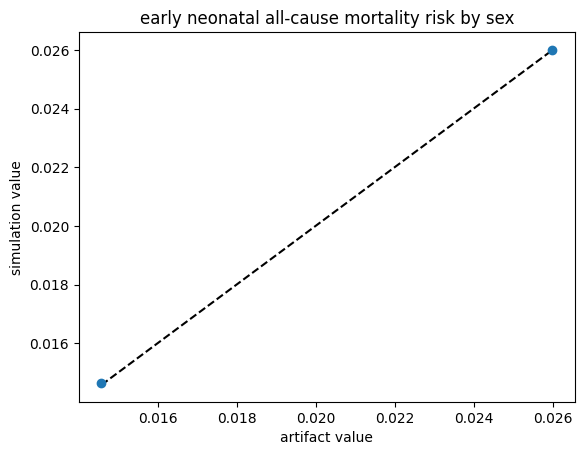

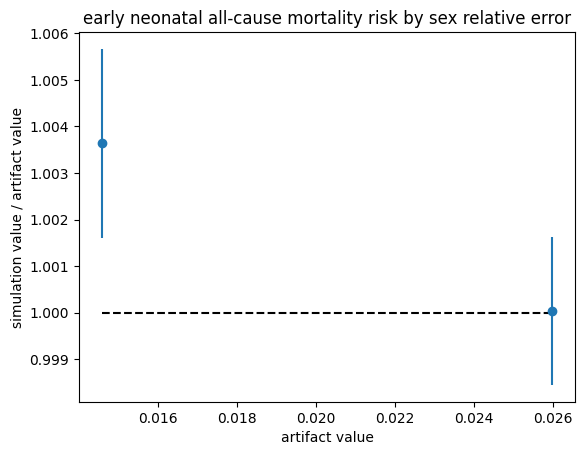

In [40]:
fuzzy_check(mortality_risk, enn_acmrisk_targets, "early neonatal all-cause mortality risk")

#### Check individual steps in calculation of all-cause mortality risk

In [41]:
def step_by_step_check_acmrisk(age_group_start, age_group_end):
    acmrisk_targets = get_acmrisk_targets(age_group_start, age_group_end)
    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/86f8e36e8f781549cd6671cba9ad33912638dc4a/src/vivarium_gates_mncnh/components/mortality.py#L357-L361
    print('Initial mortality risk')
    initial_all_cause_mortality_risk = main_sim_components['neonatal_mortality'].lookup_tables["all_cause_mortality_risk"](alive_idx)
    # Does not vary except by sex
    assert (initial_all_cause_mortality_risk.groupby(pop.sex_of_child).nunique() == 1).all()
    # Exactly matches artifact values
    assert np.allclose(initial_all_cause_mortality_risk.groupby(pop.sex_of_child).mean(), acmrisk_targets, rtol=0, atol=1e-14)
    display(initial_all_cause_mortality_risk.groupby(pop.sex_of_child).mean())

    # Next (conceptually) is applying LBWSG PAF and RR
    lbwsg_paf = main_sim_components['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk'].lookup_tables["population_attributable_fraction"](alive_idx)
    if age_group_start == 0 and age_group_end == LATE_NEONATAL_AGE_START:
        age_group_name = 'early_neonatal'
    elif age_group_start == LATE_NEONATAL_AGE_START and age_group_end == LATE_NEONATAL_AGE_END:
        age_group_name = 'late_neonatal'
    else:
        raise ValueError("Unknown age group")

    lbwsg_rr = pop.loc[alive_idx][f'effect_of_low_birth_weight_and_short_gestation_on_{age_group_name}_all_causes_relative_risk']

    acmrisk_after_lbwsg = initial_all_cause_mortality_risk * (1 - lbwsg_paf) * lbwsg_rr
    print('After LBWSG:')
    display(acmrisk_after_lbwsg.groupby(pop.sex_of_child).describe())

    fuzzy_check(acmrisk_after_lbwsg, acmrisk_targets, "ACMRisk after LBWSG")

    # Check that we've exactly replicated everything up to mutators
    assert np.allclose(acmrisk_after_lbwsg, main_sim_components['neonatal_mortality'].death_in_age_group.source(alive_idx), rtol=0, atol=1e-14)

    # Now we add in CSMRisk-based modifications
    print('Mutators:')
    display(main_sim_components['neonatal_mortality'].death_in_age_group.mutators)

    working_acmrisk = acmrisk_after_lbwsg

    for mutator in main_sim_components['neonatal_mortality'].death_in_age_group.mutators:
        print(f'After {mutator}')
        working_acmrisk = mutator(alive_idx, working_acmrisk)
        # Add acceptable deviation in LNN for CPAP PAF not being age-specific
        acceptable_deviation = 0.01 if age_group_name == 'late_neonatal' else None
        fuzzy_check(working_acmrisk, acmrisk_targets, "ACMRisk after mutator", acceptable_deviation=acceptable_deviation)

    # Check that we've exactly replicated everything
    assert np.allclose(working_acmrisk, main_sim_components['neonatal_mortality'].death_in_age_group(alive_idx), rtol=0, atol=1e-14)

Initial mortality risk


sex_of_child
Female    0.014576
Male      0.025991
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.014598,0.047577,0.002567,0.002567,0.002983,0.005495,0.787392
Male,2802480.0,0.025952,0.068673,0.003953,0.003961,0.005156,0.011601,0.840535


Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.014598,0.047577,0.002567,0.002567,0.002983,0.005495,0.787392
Male,2802480.0,0.025952,0.068673,0.003953,0.003961,0.005156,0.011601,0.840535


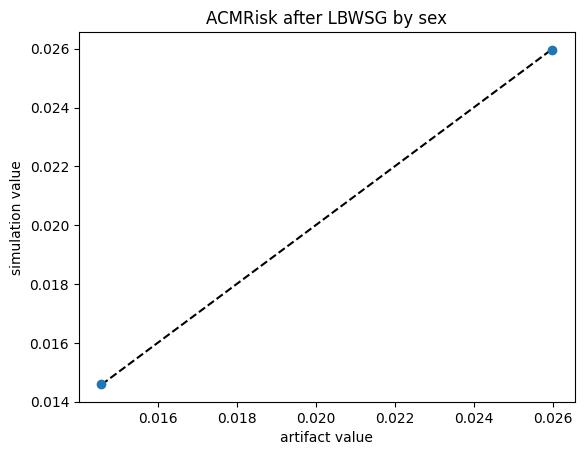

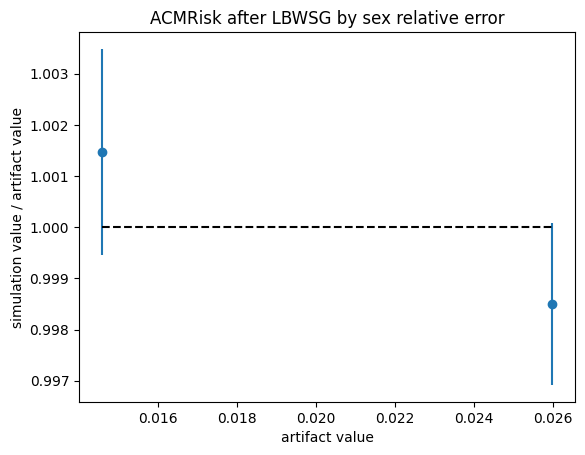

Mutators:


[ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.1.preterm_birth.neonatal_preterm_birth_with_rds.modify_death_in_age_group_probability', component=PretermBirth(neonatal_cause=neonatal_preterm_birth_with_rds)),
 ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.2.preterm_birth.neonatal_preterm_birth_without_rds.modify_death_in_age_group_probability', component=PretermBirth(neonatal_cause=neonatal_preterm_birth_without_rds)),
 ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.3.neonatal_cause.neonatal_sepsis_and_other_neonatal_infections.modify_death_in_age_group_probability', component=NeonatalCause(neonatal_cause=neonatal_sepsis_and_other_neonatal_infections)),
 ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.4.neonatal_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.modify_death_in_age_group_probability', component=NeonatalCause(neonata

After ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.1.preterm_birth.neonatal_preterm_birth_with_rds.modify_death_in_age_group_probability', component=PretermBirth(neonatal_cause=neonatal_preterm_birth_with_rds))
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.014629,0.048067,0.002567,0.002567,0.002983,0.005491,0.826524
Male,2802480.0,0.025992,0.069376,0.003953,0.003961,0.005152,0.011578,0.890416


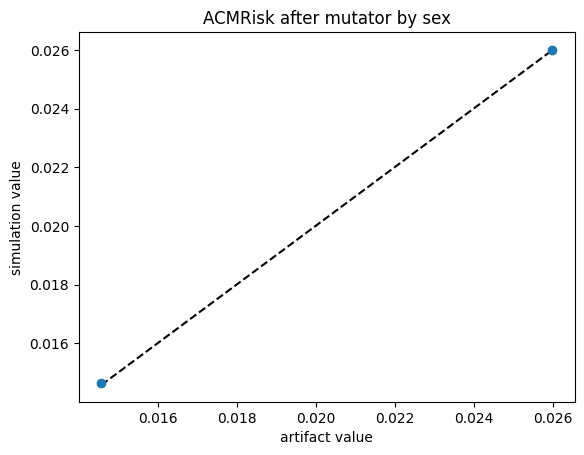

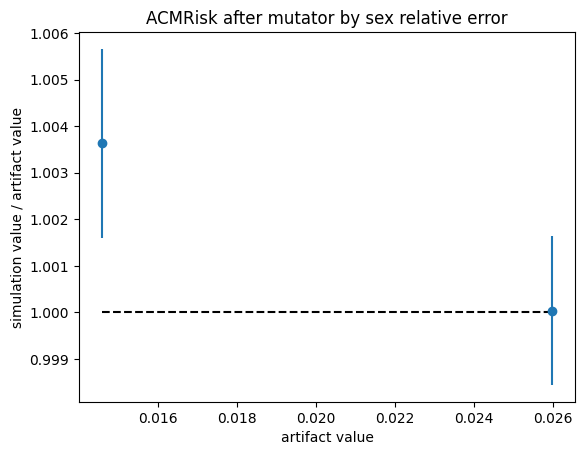

After ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.2.preterm_birth.neonatal_preterm_birth_without_rds.modify_death_in_age_group_probability', component=PretermBirth(neonatal_cause=neonatal_preterm_birth_without_rds))
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.014629,0.048067,0.002567,0.002567,0.002983,0.005491,0.826524
Male,2802480.0,0.025992,0.069376,0.003953,0.003961,0.005152,0.011578,0.890416


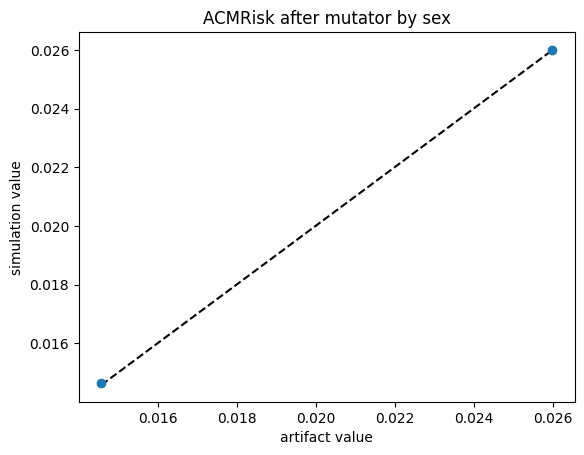

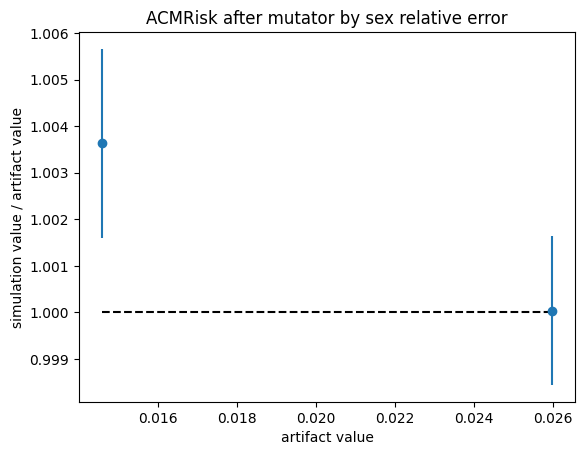

After ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.3.neonatal_cause.neonatal_sepsis_and_other_neonatal_infections.modify_death_in_age_group_probability', component=NeonatalCause(neonatal_cause=neonatal_sepsis_and_other_neonatal_infections))
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.014629,0.048068,0.002559,0.002575,0.002984,0.005491,0.828962
Male,2802480.0,0.025992,0.069377,0.003932,0.003974,0.005152,0.011581,0.894904


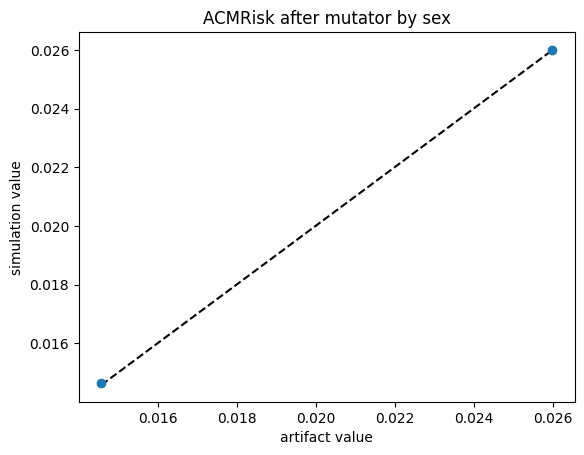

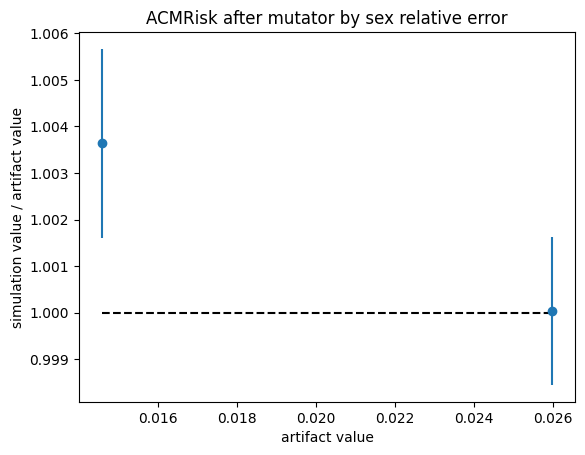

After ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.4.neonatal_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.modify_death_in_age_group_probability', component=NeonatalCause(neonatal_cause=neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma))
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.014629,0.048068,0.002559,0.002575,0.002984,0.005491,0.828962
Male,2802480.0,0.025992,0.069377,0.003932,0.003974,0.005152,0.011581,0.894904


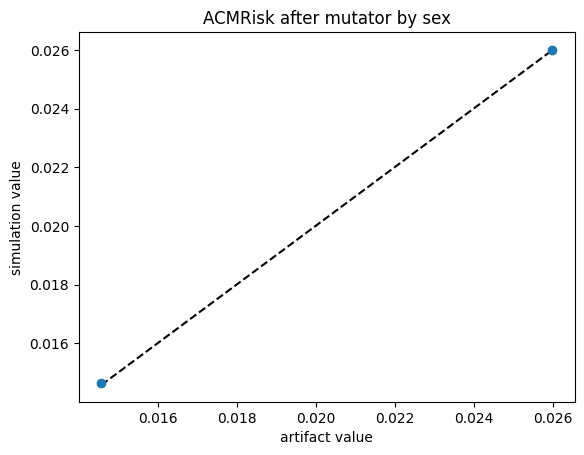

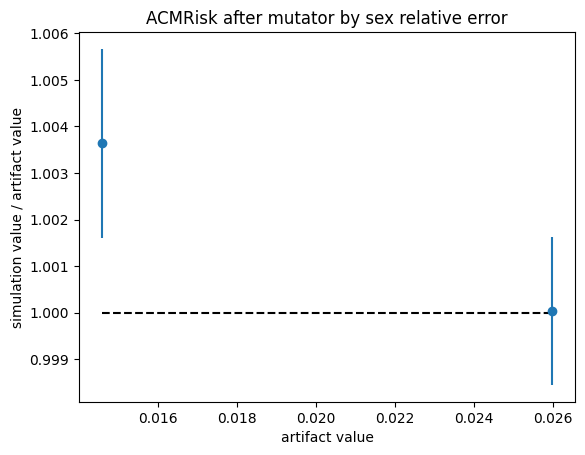

In [42]:
step_by_step_check_acmrisk(0, LATE_NEONATAL_AGE_START)

### Check cause-specific mortality risks

In [43]:
# Check that our transfer above actually worked
assert (
    set(main_sim_components['neonatal_cause.neonatal_sepsis_and_other_neonatal_infections'].lbwsg_acmr_paf(main_sim.get_population().index).unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [44]:
# Check that our transfer above actually worked
assert (
    set(main_sim_components['preterm_birth.neonatal_preterm_birth_with_rds'].lbwsg_acmr_paf(main_sim.get_population().index).unique())
    <=
    set(preterm_csmr_pafs['value'].unique())
)

In [45]:
def get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end):
    return (
        art.load(f'cause.{artifact_cause_name}.mortality_risk')[f'draw_{draw_num}'].reset_index()
        .pipe(lambda df: df[(df.child_age_start == age_group_start) & (df.child_age_end == age_group_end)])
        .drop(columns=['child_age_start', 'child_age_end', 'year_start', 'year_end'])
        .set_index('sex_of_child')
        [f'draw_{draw_num}']
    )

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Targets


sex_of_child
Female    0.004124
Male      0.009226
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.004130,0.013460,0.000726,0.000726,0.000844,0.001555,0.222757
Male,2802480.0,0.009212,0.024377,0.001403,0.001406,0.001830,0.004118,0.298372


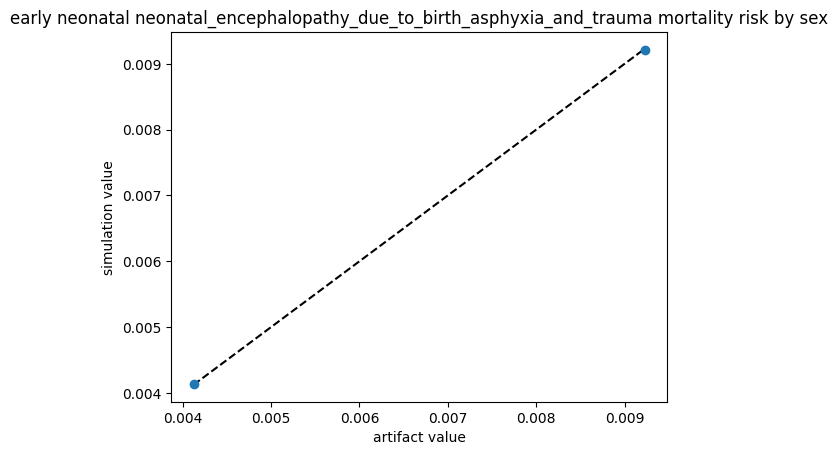

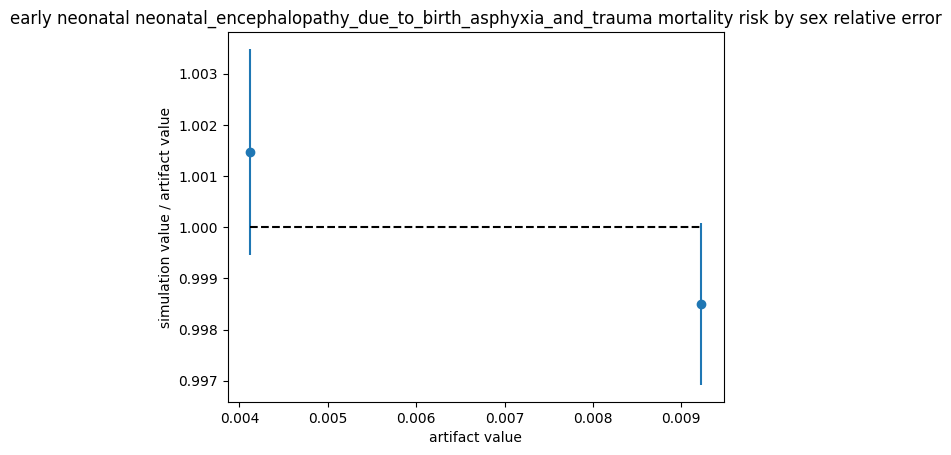

neonatal_sepsis_and_other_neonatal_infections
Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.000863,0.002816,0.000144,0.000160,0.000177,0.000324,0.048963
Male,2802480.0,0.002645,0.007009,0.000382,0.000424,0.000525,0.001190,0.090144


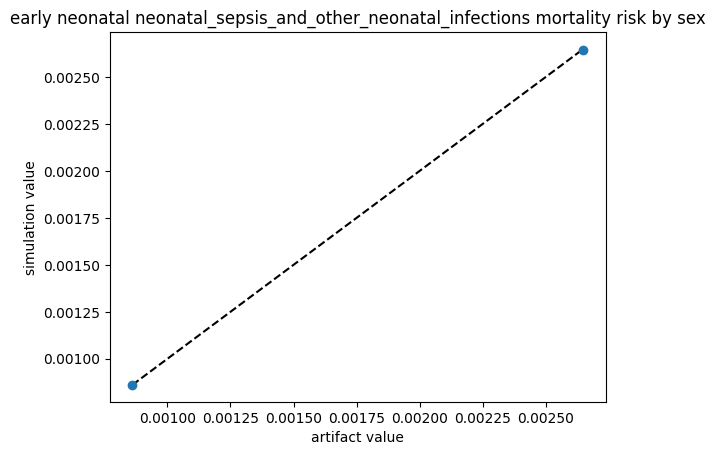

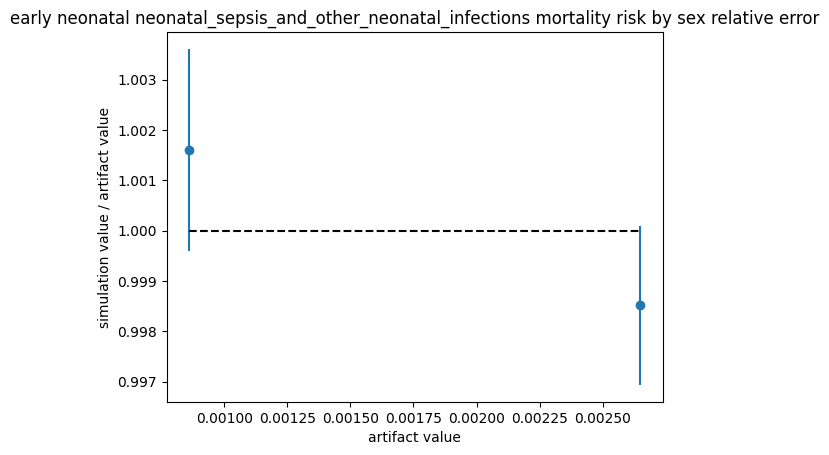

neonatal_preterm_birth
Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.003264,0.017921,0.0,0.0,0.0,0.0,0.342001
Male,2802480.0,0.007160,0.029425,0.0,0.0,0.0,0.0,0.435946


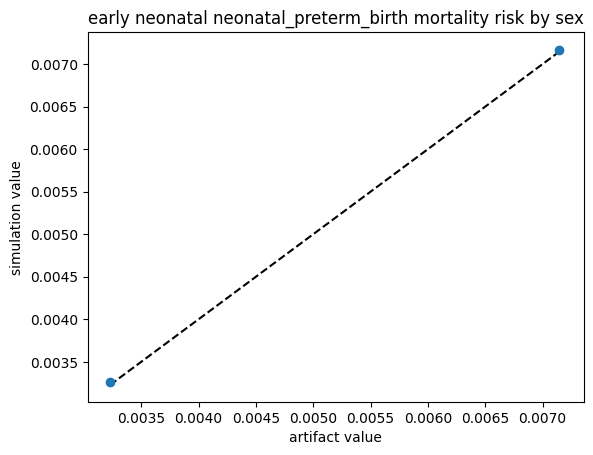

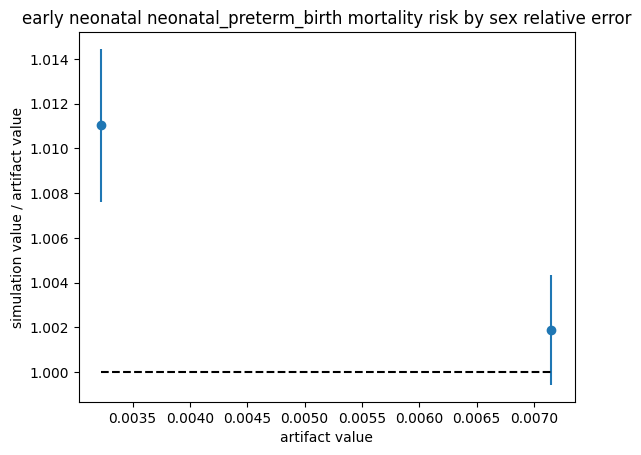

neonatal_preterm_birth_with_rds
Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.002779,0.015429,0.0,0.0,0.0,0.0,0.296571
Male,2802480.0,0.006092,0.025336,0.0,0.0,0.0,0.0,0.378036


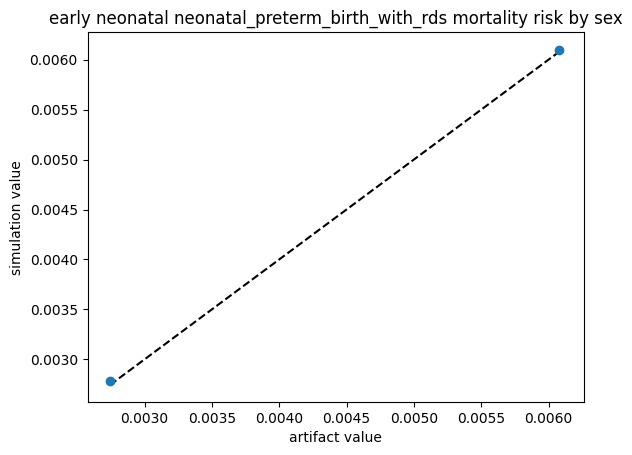

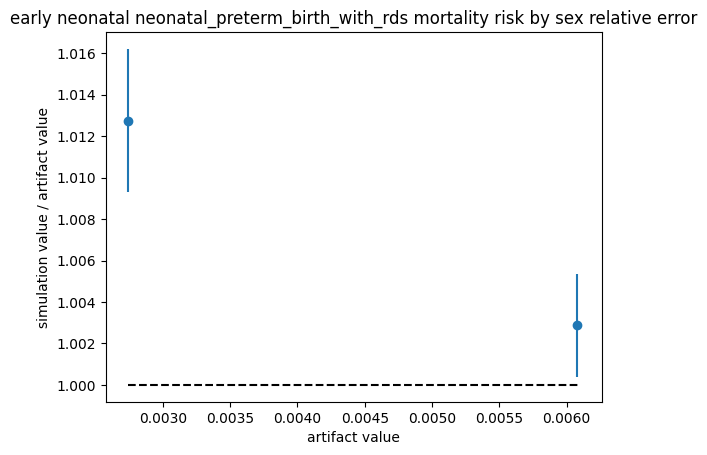

neonatal_preterm_birth_without_rds
Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.000485,0.002568,0.0,0.0,0.0,0.0,0.04543
Male,2802480.0,0.001068,0.004228,0.0,0.0,0.0,0.0,0.05791


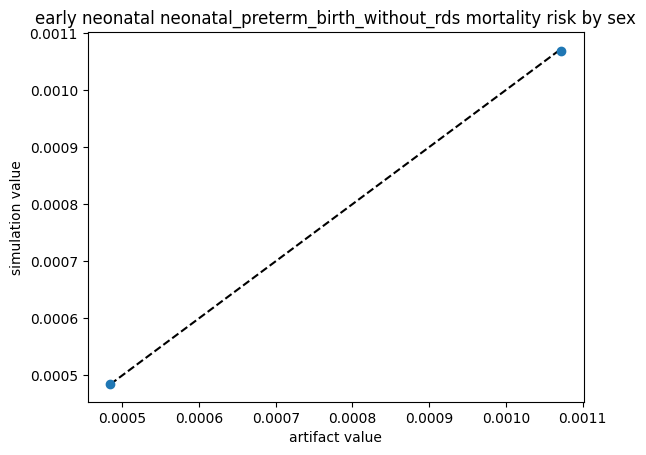

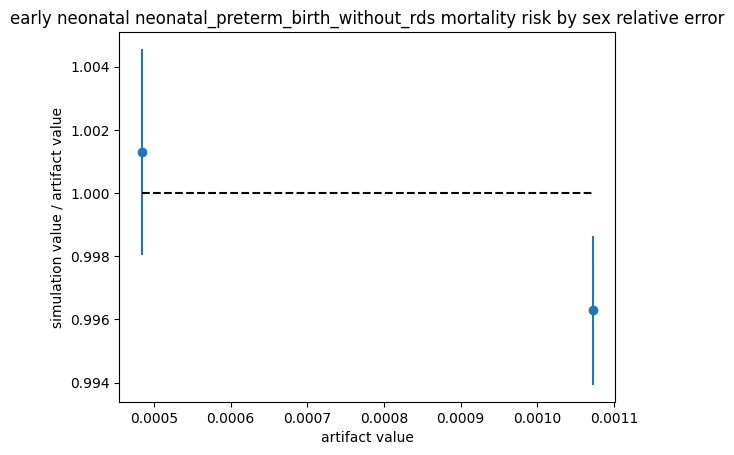

In [46]:
from vivarium_gates_mncnh.constants.data_values import PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY

CAUSE_NAME_TO_CSMRISK_PIPELINES = {
    'neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma': ['encephalopathy_csmr'],
    'neonatal_sepsis_and_other_neonatal_infections': ['sepsis_csmr'],
    'neonatal_preterm_birth_with_rds': ['preterm_with_rds_csmr'],
    'neonatal_preterm_birth_without_rds': ['preterm_without_rds_csmr'],
    'neonatal_preterm_birth': ['preterm_with_rds_csmr', 'preterm_without_rds_csmr'],
}

NEONATAL_CAUSES = [
    'neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma',
    'neonatal_sepsis_and_other_neonatal_infections',
    'neonatal_preterm_birth',
    'neonatal_preterm_birth_with_rds',
    'neonatal_preterm_birth_without_rds',
]

def check_csmrisks(age_group_start, age_group_end):
    for cause_name in NEONATAL_CAUSES:
        print(cause_name)

        pipeline_names = CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name]
        csmrisk_values = 0
        for pipeline_name in pipeline_names:
            csmrisk_values += (
                getattr(main_sim_components['neonatal_mortality'], pipeline_name)(alive_idx)
            )

        artifact_cause_name = cause_name.replace('_with_rds', '').replace('_without_rds', '')
        csmrisk_targets = get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end)

        if cause_name == 'neonatal_preterm_birth_with_rds':
            csmrisk_targets *= PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
        elif cause_name == 'neonatal_preterm_birth_without_rds':
            csmrisk_targets *= (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)

        # Add acceptable deviation in LNN for CPAP PAF not being age-specific
        acceptable_deviation = (
            0.02
            if age_group_start == LATE_NEONATAL_AGE_START and cause_name in ('neonatal_preterm_birth', 'neonatal_preterm_birth_with_rds')
            else None
        )
        fuzzy_check(csmrisk_values, csmrisk_targets, f"early neonatal {cause_name} mortality risk", acceptable_deviation=acceptable_deviation)

check_csmrisks(0, LATE_NEONATAL_AGE_START)

#### Check frequency of negative other-causes mortality, and impact

This isn't the best check because it is only for a single draw and location. In the one I've chosen, this rarely happens, apparently.

In [47]:
csmrisk_pipeline_names = result = sorted({item for values in CAUSE_NAME_TO_CSMRISK_PIPELINES.values() for item in values})
csmrisk_pipeline_names

['encephalopathy_csmr',
 'preterm_with_rds_csmr',
 'preterm_without_rds_csmr',
 'sepsis_csmr']

In [48]:
total_csmrisk = 0

for pipeline_name in csmrisk_pipeline_names:
    total_csmrisk += (
        getattr(main_sim_components['neonatal_mortality'], pipeline_name)(alive_idx).rename('total_csmrisk')
    )

total_csmrisk

2          0.000877
3          0.001793
4          0.002210
5          0.039813
8          0.034751
             ...   
9999993    0.035968
9999995    0.002665
9999996    0.001827
9999997    0.041898
9999999    0.001006
Name: total_csmrisk, Length: 5440956, dtype: float64

In [49]:
total_csmrisk.describe()

count    5.440956e+06
mean     1.379923e-02
std      4.804029e-02
min      8.698213e-04
25%      1.040175e-03
50%      1.829137e-03
75%      4.143938e-03
max      8.244612e-01
Name: total_csmrisk, dtype: float64

In [50]:
(total_csmrisk > mortality_risk).mean()

0.0

In [51]:
# Expect CSMRisks to be underestimated by this amount as a result
(total_csmrisk - mortality_risk).clip(0).sum() / total_csmrisk.sum()

0.0

#### Check individual steps in calculation of cause-specific mortality risks

In [52]:
def step_by_step_check_csmrisk(cause_name, age_group_start, age_group_end):
    artifact_cause_name = cause_name.replace('_with_rds', '').replace('_without_rds', '')
    csmrisk_targets = get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end)

    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/86f8e36e8f781549cd6671cba9ad33912638dc4a/src/vivarium_gates_mncnh/components/mortality.py#L357-L361
    print('Initial cause-specific mortality risk')
    component_name = ('preterm_birth.' if 'preterm_birth' in cause_name else 'neonatal_cause.') + cause_name
    component = main_sim_components[component_name]
    initial_csmrisk = component.lookup_tables["csmrisk"](alive_idx)
    # Does not vary except by sex
    assert (initial_csmrisk.groupby(pop.sex_of_child).nunique() == 1).all()
    # Exactly matches artifact values
    assert np.allclose(initial_csmrisk.groupby(pop.sex_of_child).mean(), csmrisk_targets, rtol=0, atol=1e-14)
    display(initial_csmrisk.groupby(pop.sex_of_child).mean())

    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/7886d2bcb71fd2c3e497997a2bcf44c43569b8ab/src/vivarium_gates_mncnh/components/neonatal_causes.py#L116-L136
    global any_failures
    if 'preterm_birth' in cause_name:
        # Next step (conceptually) is limiting to preterm babies
        print('Preterm prevalence:')
        prevalence = component.lookup_tables["prevalence"](alive_idx)
        # Does not vary except by sex
        assert (prevalence.groupby(pop.sex_of_child).nunique() == 1).all()
        display(prevalence.groupby(pop.sex_of_child).mean())

        ga_greater_than_37 = pop.loc[alive_idx]['gestational_age_exposure'] >= 37.0
        for sex in ['Female', 'Male']:
            try:
                fuzzy_checker.fuzzy_assert_proportion(
                    (~ga_greater_than_37)[pop.loc[alive_idx].sex_of_child == sex].sum(),
                    (pop.loc[alive_idx].sex_of_child == sex).sum(),
                    prevalence[pop.sex_of_child == sex].mean()
                )
            except AssertionError as e:
                print(e)
                any_failures = True
    
        limited_csmrisk_preterm = initial_csmrisk / prevalence
        limited_csmrisk_preterm.loc[ga_greater_than_37] = 0
        limited_csmrisk_preterm.groupby(pop.sex_of_child).mean()

        fuzzy_check(limited_csmrisk_preterm, csmrisk_targets, "CSMRisk after limiting to preterm")

        working_csmrisk = limited_csmrisk_preterm

        if cause_name == 'neonatal_preterm_birth_with_rds':
            working_csmrisk = working_csmrisk * PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
            csmrisk_targets = csmrisk_targets * PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
        elif cause_name == 'neonatal_preterm_birth_without_rds':
            working_csmrisk = working_csmrisk * (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)
            csmrisk_targets = csmrisk_targets * (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)
        
        fuzzy_check(working_csmrisk, csmrisk_targets, "CSMRisk after splitting to subcause")
    else:
        working_csmrisk = initial_csmrisk

    # Next (conceptually) is applying LBWSG PAF/normalizing constant and RR
    lbwsg_paf = main_sim_components[f'risk_effect.low_birth_weight_and_short_gestation_on_cause.{cause_name}.cause_specific_mortality_risk'].lookup_tables["population_attributable_fraction"](alive_idx)
    if age_group_start == 0 and age_group_end == LATE_NEONATAL_AGE_START:
        age_group_name = 'early_neonatal'
    elif age_group_start == LATE_NEONATAL_AGE_START and age_group_end == LATE_NEONATAL_AGE_END:
        age_group_name = 'late_neonatal'
    else:
        raise ValueError("Unknown age group")

    lbwsg_rr = pop.loc[alive_idx][f'effect_of_low_birth_weight_and_short_gestation_on_{age_group_name}_{cause_name}_relative_risk']

    csmrisk_after_lbwsg = working_csmrisk * (1 - lbwsg_paf) * lbwsg_rr
    print('After LBWSG:')
    display(csmrisk_after_lbwsg.groupby(pop.sex_of_child).describe())

    fuzzy_check(csmrisk_after_lbwsg, csmrisk_targets, "CSMRisk after LBWSG")

    pipeline_names = CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name]
    assert len(pipeline_names) == 1
    pipeline = getattr(main_sim_components['neonatal_mortality'], pipeline_names[0])

    # Check that we've exactly replicated everything up to mutators
    assert np.allclose(csmrisk_after_lbwsg, pipeline.source(alive_idx), rtol=0, atol=1e-14)

    # Now we add in intervention-based modifications
    print('Mutators:')
    display(pipeline.mutators)

    working_csmrisk = csmrisk_after_lbwsg

    for mutator in pipeline.mutators:
        print(f'After {mutator}')
        working_csmrisk = mutator(alive_idx, working_csmrisk)
        # Add acceptable deviation in LNN for CPAP PAF not being age-specific
        acceptable_deviation = (
            0.02
            if age_group_name == 'late_neonatal' and cause_name in ('neonatal_preterm_birth', 'neonatal_preterm_birth_with_rds')
            else None
        )
        fuzzy_check(working_csmrisk, csmrisk_targets, "CSMRisk after mutator", acceptable_deviation=acceptable_deviation)

    # Check that we've exactly replicated everything
    assert np.allclose(working_csmrisk, pipeline(alive_idx), rtol=0, atol=1e-14)

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Initial cause-specific mortality risk


sex_of_child
Female    0.004124
Male      0.009226
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.004130,0.013460,0.000726,0.000726,0.000844,0.001555,0.222757
Male,2802480.0,0.009212,0.024377,0.001403,0.001406,0.001830,0.004118,0.298372


Targets


sex_of_child
Female    0.004124
Male      0.009226
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.004130,0.013460,0.000726,0.000726,0.000844,0.001555,0.222757
Male,2802480.0,0.009212,0.024377,0.001403,0.001406,0.001830,0.004118,0.298372


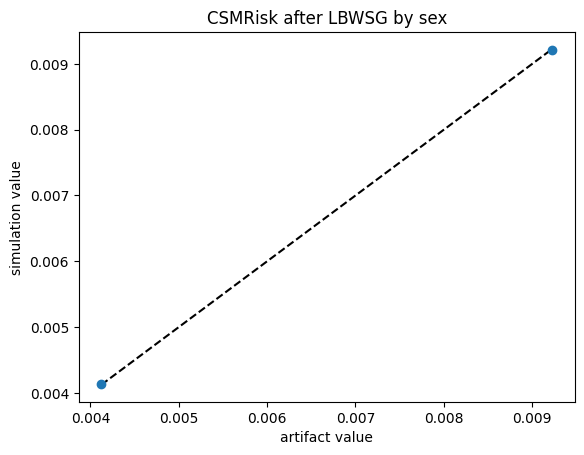

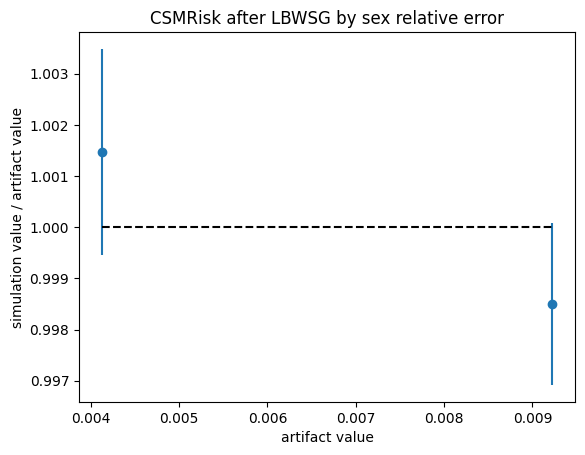

Mutators:


[]

neonatal_sepsis_and_other_neonatal_infections
Initial cause-specific mortality risk


sex_of_child
Female    0.000861
Male      0.002649
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.000863,0.002811,0.000152,0.000152,0.000176,0.000325,0.046525
Male,2802480.0,0.002645,0.006998,0.000403,0.000404,0.000525,0.001182,0.085655


Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.000863,0.002811,0.000152,0.000152,0.000176,0.000325,0.046525
Male,2802480.0,0.002645,0.006998,0.000403,0.000404,0.000525,0.001182,0.085655


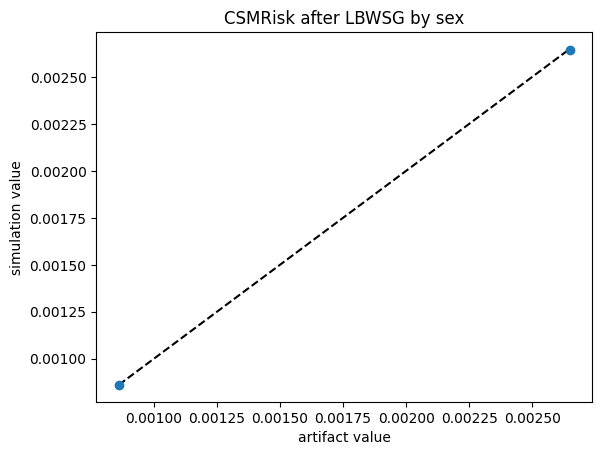

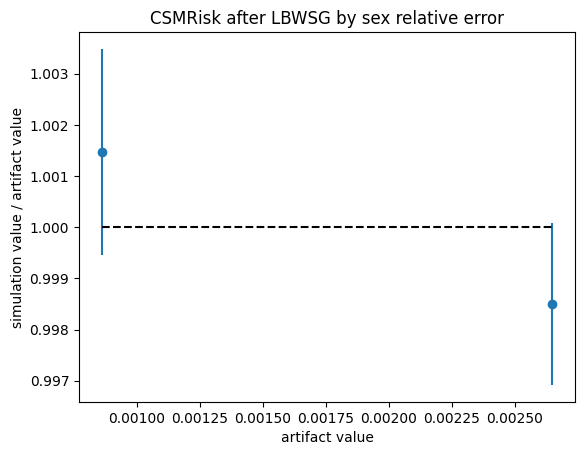

Mutators:


[ValueModifier(resource_type='value_modifier', name='neonatal_sepsis_and_other_neonatal_infections.csmr.1.intervention_risk_effect.antibiotics.modify_target_pipeline', component=InterventionRiskEffect(lack_of_intervention_risk=antibiotics)),
 ValueModifier(resource_type='value_modifier', name='neonatal_sepsis_and_other_neonatal_infections.csmr.2.intervention_risk_effect.probiotics.modify_target_pipeline', component=InterventionRiskEffect(lack_of_intervention_risk=probiotics))]

After ValueModifier(resource_type='value_modifier', name='neonatal_sepsis_and_other_neonatal_infections.csmr.1.intervention_risk_effect.antibiotics.modify_target_pipeline', component=InterventionRiskEffect(lack_of_intervention_risk=antibiotics))
Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.000863,0.002816,0.000144,0.000160,0.000177,0.000324,0.048963
Male,2802480.0,0.002645,0.007009,0.000382,0.000424,0.000525,0.001190,0.090144


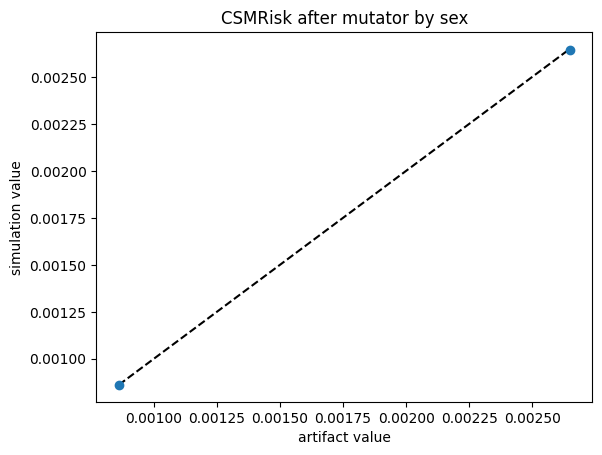

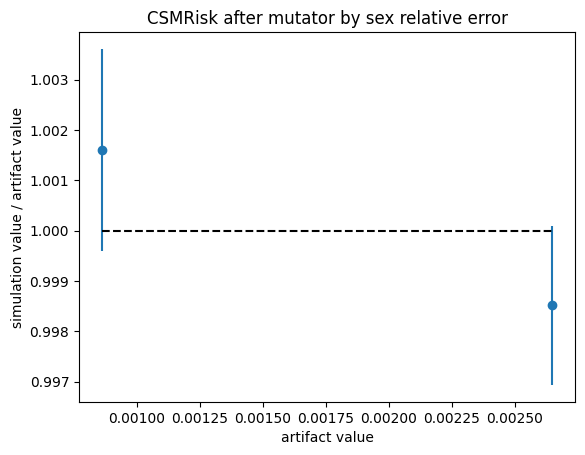

After ValueModifier(resource_type='value_modifier', name='neonatal_sepsis_and_other_neonatal_infections.csmr.2.intervention_risk_effect.probiotics.modify_target_pipeline', component=InterventionRiskEffect(lack_of_intervention_risk=probiotics))
Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.000863,0.002816,0.000144,0.000160,0.000177,0.000324,0.048963
Male,2802480.0,0.002645,0.007009,0.000382,0.000424,0.000525,0.001190,0.090144


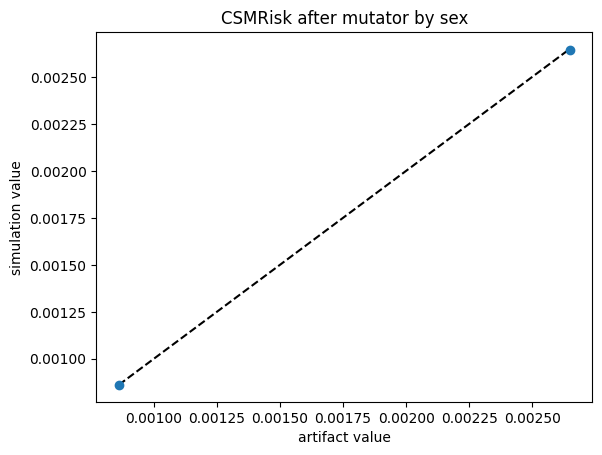

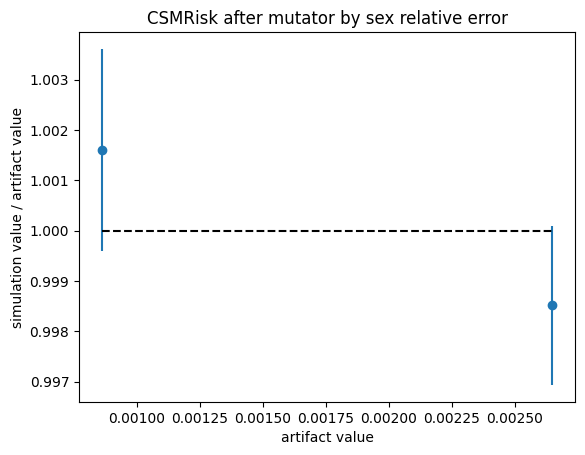

neonatal_preterm_birth_with_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.003228
Male      0.007147
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.139787
Male      0.190916
Name: value, dtype: float64

Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.003231,0.008012,0.0,0.0,0.0,0.0,0.023095
Male,2802480.0,0.007149,0.014714,0.0,0.0,0.0,0.0,0.037435


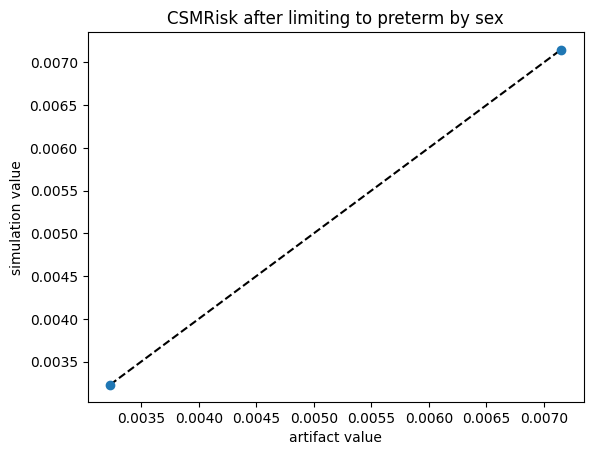

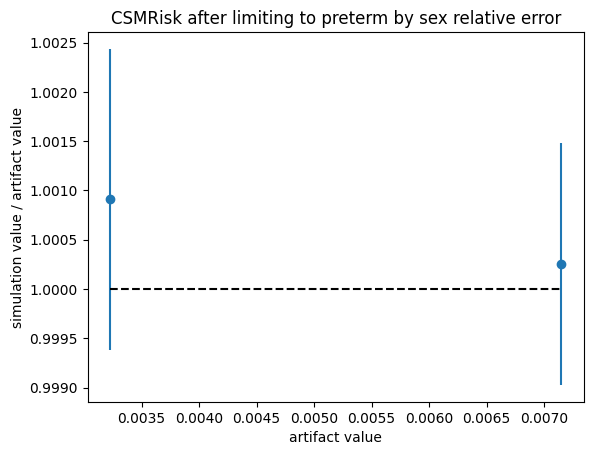

Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.002747,0.006810,0.0,0.0,0.0,0.0,0.019631
Male,2802480.0,0.006076,0.012507,0.0,0.0,0.0,0.0,0.031820


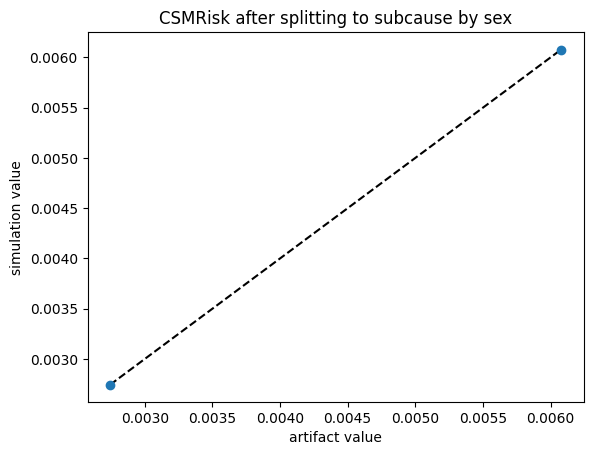

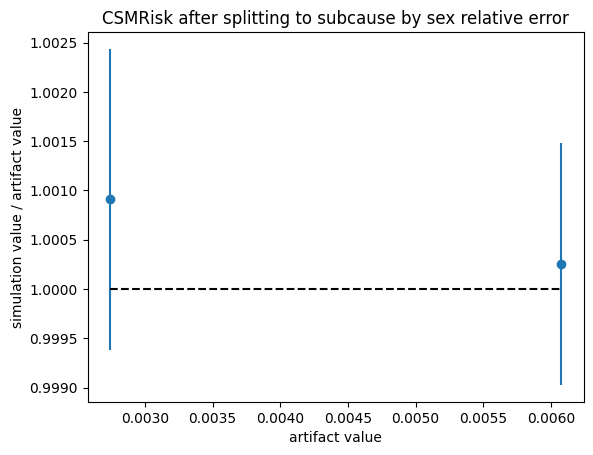

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.002748,0.014549,0.0,0.0,0.0,0.0,0.257439
Male,2802480.0,0.006052,0.023960,0.0,0.0,0.0,0.0,0.328155


Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.002748,0.014549,0.0,0.0,0.0,0.0,0.257439
Male,2802480.0,0.006052,0.023960,0.0,0.0,0.0,0.0,0.328155


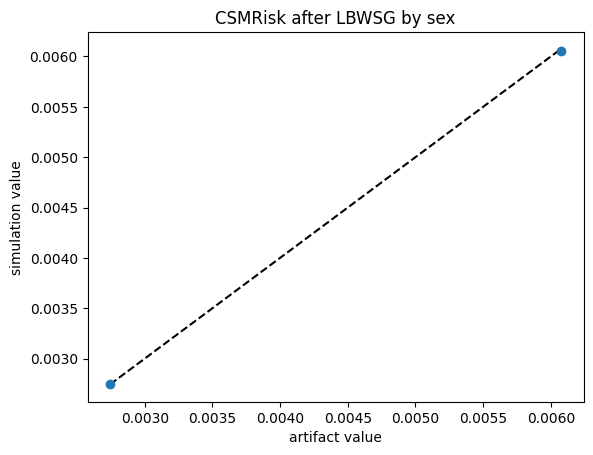

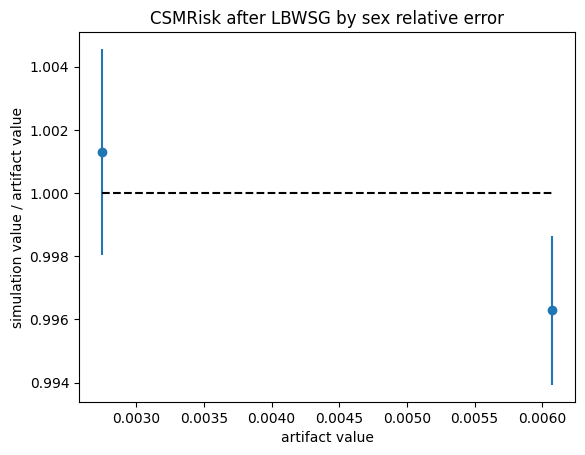

Mutators:


[ValueModifier(resource_type='value_modifier', name='neonatal_preterm_birth_with_rds.csmr.1.cpap_and_acs_risk_effect.modify_target_pipeline', component=CPAPAndACSRiskEffect())]

After ValueModifier(resource_type='value_modifier', name='neonatal_preterm_birth_with_rds.csmr.1.cpap_and_acs_risk_effect.modify_target_pipeline', component=CPAPAndACSRiskEffect())
Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.002779,0.015429,0.0,0.0,0.0,0.0,0.296571
Male,2802480.0,0.006092,0.025336,0.0,0.0,0.0,0.0,0.378036


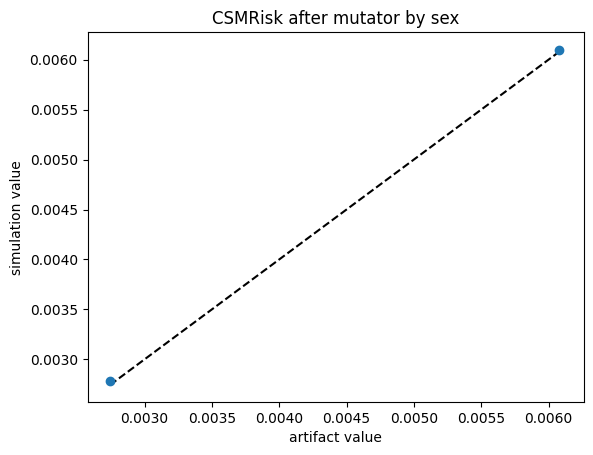

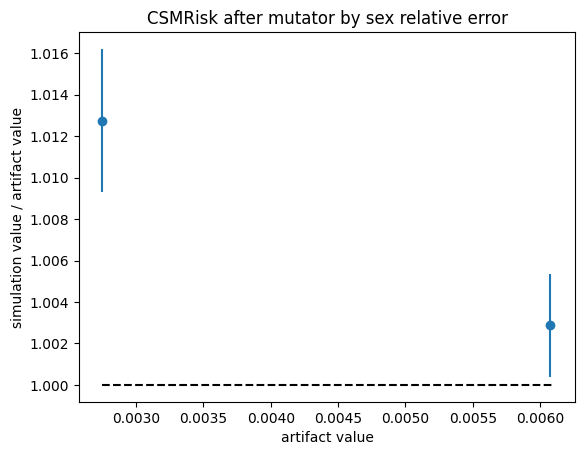

neonatal_preterm_birth_without_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.003228
Male      0.007147
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.139787
Male      0.190916
Name: value, dtype: float64

Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.003231,0.008012,0.0,0.0,0.0,0.0,0.023095
Male,2802480.0,0.007149,0.014714,0.0,0.0,0.0,0.0,0.037435


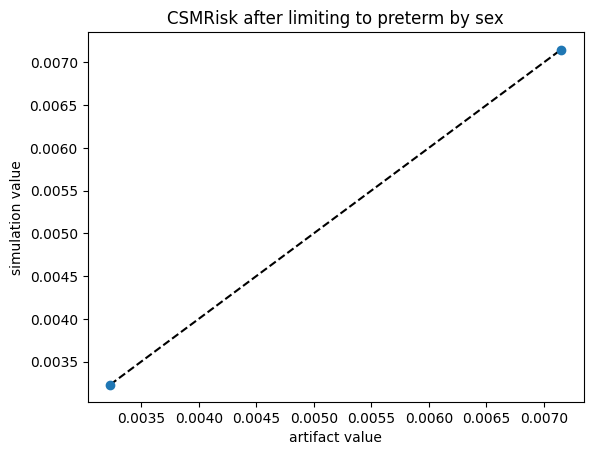

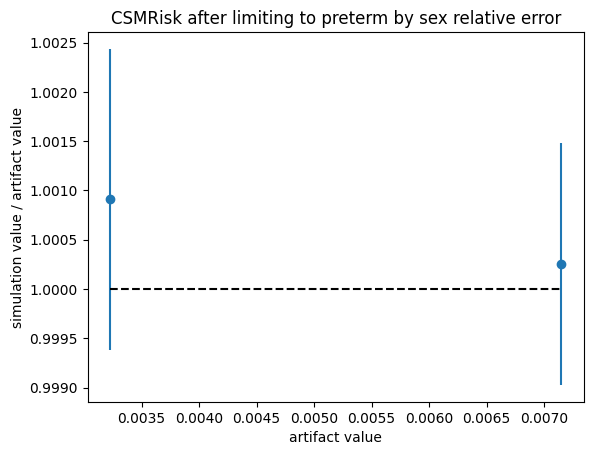

Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.000485,0.001202,0.0,0.0,0.0,0.0,0.003464
Male,2802480.0,0.001072,0.002207,0.0,0.0,0.0,0.0,0.005615


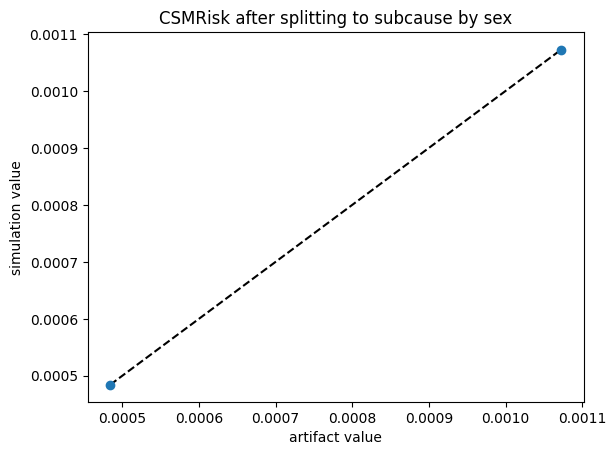

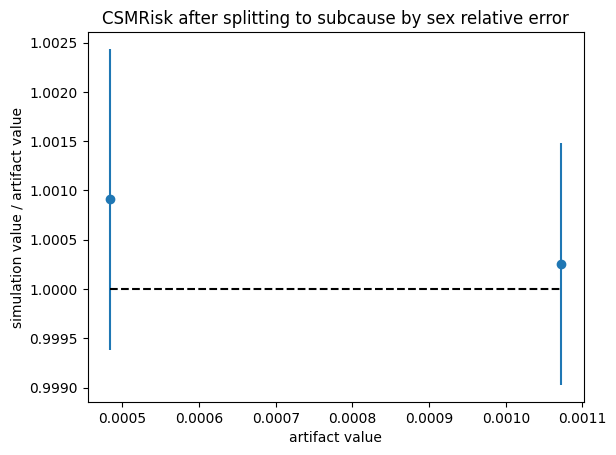

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.000485,0.002568,0.0,0.0,0.0,0.0,0.04543
Male,2802480.0,0.001068,0.004228,0.0,0.0,0.0,0.0,0.05791


Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2638476.0,0.000485,0.002568,0.0,0.0,0.0,0.0,0.04543
Male,2802480.0,0.001068,0.004228,0.0,0.0,0.0,0.0,0.05791


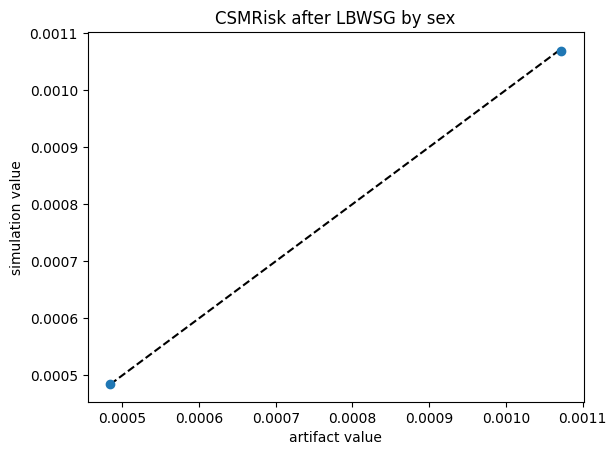

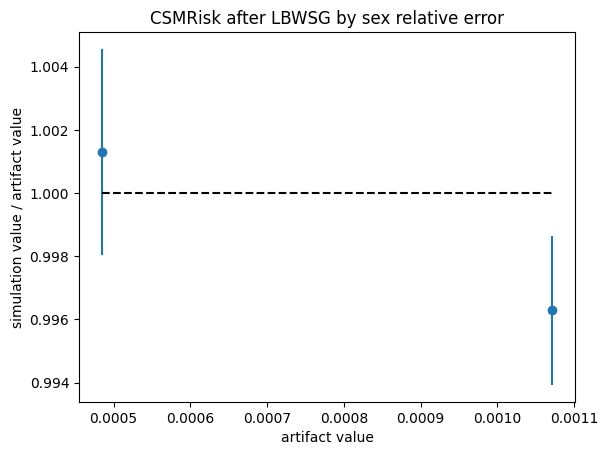

Mutators:


[]

In [53]:
for cause_name in NEONATAL_CAUSES:
    if cause_name == 'neonatal_preterm_birth':
        continue
    print(cause_name)
    step_by_step_check_csmrisk(cause_name, 0, LATE_NEONATAL_AGE_START)

## LNN mortality

### Step main sim to LNN mortality

In [54]:
get_event_name = main_sim._builder.time.simulation_event_name()
get_event_name()

'early_neonatal_mortality'

In [55]:
%%time

while get_event_name() != 'late_neonatal_mortality':
    main_sim.step()
    print(get_event_name())

2025-11-04 20:20:11.843 | INFO     | simulation_1 - vivarium.framework.engine:284 - 2025-01-13 00:00:00
late_neonatal_mortality
CPU times: user 14min 21s, sys: 10min 6s, total: 24min 27s
Wall time: 24min 19s


In [56]:
assert get_event_name() == 'late_neonatal_mortality'

In [57]:
# We now step to the *middle* of a time step
# https://github.com/ihmeuw/vivarium/blob/aeaa9e03ecbf67929a1ce94e934c2c14ececfa29/src/vivarium/framework/engine.py#L260-L268
self = main_sim
for event in self.time_step_events:
    self._lifecycle.set_state(event)
    pop_to_update = self._clock.get_active_simulants(
        self.get_population().index,
        self._clock.event_time,
    )
    # https://github.com/ihmeuw/vivarium/blob/aeaa9e03ecbf67929a1ce94e934c2c14ececfa29/src/vivarium/framework/event.py#L119-L141
    clock = self._events.clock()
    step_size = self._events.step_size()
    event_time = clock + step_size

    e = Event(
        "time_step",
        pop_to_update,
        {},
        event_time,
        step_size,
    )

    listener = None
    listeners = self.time_step_emitters[event].__self__.listeners
    for priority_bucket in listeners:
        for listener in priority_bucket:
            if listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
                break
            listener(e)
        if listener is not None and listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
            break

    if listener is not None and listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
            break

In [58]:
assert listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step"

In [59]:
assert (main_sim.get_population().pipe(lambda df: df[df.child_alive == 'alive']).child_age >= LATE_NEONATAL_AGE_START).all()
assert (main_sim.get_population().pipe(lambda df: df[df.child_alive == 'alive']).child_age < LATE_NEONATAL_AGE_END).all()

In [60]:
alive_idx = main_sim.get_population().index[main_sim.get_population()['child_alive'] == "alive"]

### Feed ENN PAFs back into the PAF sim

In [61]:
acmr_paf_components = [k for k in paf_sim_components if 'risk_effect.low_birth_weight_' in k]
acmr_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk']

In [62]:
for component in acmr_paf_components:
    update_lookup_table(paf_sim_components[component].lookup_tables['population_attributable_fraction'], acmrisk_pafs)

In [63]:
# Check that our transfer actually worked
assert (
    set(paf_sim_components[component].paf(paf_sim.get_population().index))
    <=
    set(acmrisk_pafs['value'].unique())
)

### Step PAF sim to LNN

In [64]:
%%time

assert (paf_sim.get_population().child_age < LATE_NEONATAL_AGE_START).all()
paf_sim.step()

2025-11-04 20:50:13.634 | INFO     | simulation_2 - vivarium.framework.engine:284 - 2022-01-01 00:00:00
CPU times: user 2min 1s, sys: 1min 21s, total: 3min 22s
Wall time: 3min 20s


In [65]:
assert (paf_sim.get_population().pipe(lambda df: df[df.child_alive == 'alive']).child_age >= LATE_NEONATAL_AGE_START).all()
assert (paf_sim.get_population().pipe(lambda df: df[df.child_alive == 'alive']).child_age < LATE_NEONATAL_AGE_END).all()

### Transfer PAFs and preterm prevalence to main sim

In [66]:
paf_observer = paf_sim_components['lbwsgpaf_observer.cause.all_causes.all_cause_mortality_risk']

In [67]:
paf_sim._results.gather_results(Event(
    "time_step",
    index=paf_sim.get_population().index,
    user_data={},
    time=paf_sim._clock.time,
    step_size=paf_sim._clock.step_size,
))

In [68]:
acmrisk_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk']
)
acmrisk_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.823918,0.000000,0.019178,2021,2022
1,Male,0.847904,0.000000,0.019178,2021,2022
2,Female,0.762950,0.019178,0.076712,2021,2022
3,Male,0.774988,0.019178,0.076712,2021,2022


In [69]:
preterm_csmr_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk_preterm']
)
preterm_csmr_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.957253,0.000000,0.019178,2021,2022
1,Male,0.951496,0.000000,0.019178,2021,2022
2,Female,0.929065,0.019178,0.076712,2021,2022
3,Male,0.912466,0.019178,0.076712,2021,2022


In [70]:
acmr_paf_components = [k for k in main_sim_components if 'risk_effect.low_birth_weight_' in k and 'preterm' not in k]
acmr_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk']

In [71]:
for component in acmr_paf_components:
    update_lookup_table(main_sim_components[component].lookup_tables['population_attributable_fraction'], acmrisk_pafs)

In [72]:
preterm_paf_components = [k for k in main_sim_components if ('risk_effect.low_birth_weight_' in k and 'preterm' in k) or ('preterm_birth.' in k)]
preterm_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_with_rds.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_without_rds.cause_specific_mortality_risk',
 'preterm_birth.neonatal_preterm_birth_with_rds',
 'preterm_birth.neonatal_preterm_birth_without_rds']

In [73]:
for component in preterm_paf_components:
    lookup_tables = main_sim_components[component].lookup_tables
    lookup_table_name = 'population_attributable_fraction' if 'population_attributable_fraction' in lookup_tables else 'paf'
    update_lookup_table(lookup_tables[lookup_table_name], preterm_csmr_pafs)

In [74]:
late_neonatal_preterm_prevalence = paf_sim.get_results()['calculated_late_neonatal_preterm_prevalence'].assign(
    child_age_start=LATE_NEONATAL_AGE_START,
    child_age_end=LATE_NEONATAL_AGE_END,
    year_start=2023,
    year_end=2024,
).rename(columns={"child_sex": "sex_of_child"})
late_neonatal_preterm_prevalence

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.133331,0.019178,0.076712,2023,2024
1,Male,0.180029,0.019178,0.076712,2023,2024


In [75]:
preterm_prevalence_components = [k for k in main_sim_components if 'preterm_birth.' in k]

for component in preterm_prevalence_components:
    lookup_table = main_sim_components[component].lookup_tables["prevalence"]
    enn_data = lookup_table.data[lookup_table.data.child_age_start == 0]
    update_lookup_table(lookup_table, pd.concat([enn_data, late_neonatal_preterm_prevalence], ignore_index=True))

In [76]:
assert (
    set(main_sim_components['preterm_birth.neonatal_preterm_birth_with_rds'].lookup_tables["prevalence"](alive_idx).unique())
    <=
    set(late_neonatal_preterm_prevalence['value'].unique())
)

### Check all-cause mortality risk

In [77]:
# Check that our transfer above actually worked
assert (
    set(main_sim_components['neonatal_mortality'].acmr_paf(main_sim.get_population().index).unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [78]:
# https://github.com/ihmeuw/vivarium_gates_mncnh/blob/9502fba51790f522523b8cd2925e539a692babf6/src/vivarium_gates_mncnh/components/mortality.py#L281-L283
pop = main_sim.get_population()
alive_idx = pop.index[pop['child_alive'] == "alive"]
mortality_risk = main_sim_components['neonatal_mortality'].death_in_age_group(alive_idx)

In [79]:
acmrisk_targets = get_acmrisk_targets(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)
acmrisk_targets

sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.004315,0.013887,0.001013,0.001205,0.001710,0.003066,0.588759
Male,2729790.0,0.007291,0.019343,0.001628,0.002192,0.003176,0.005881,0.904885


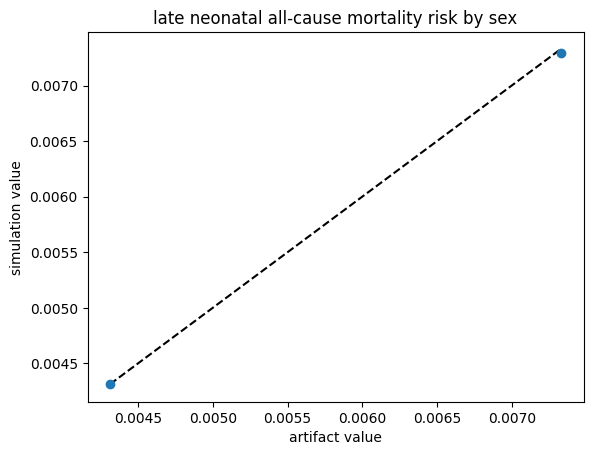

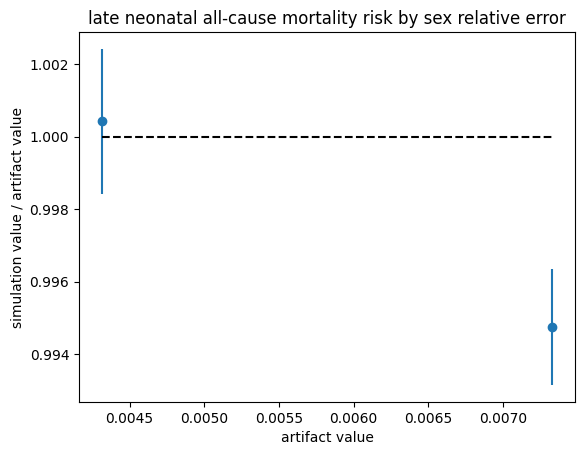

In [80]:
fuzzy_check(mortality_risk, acmrisk_targets, "late neonatal all-cause mortality risk", acceptable_deviation=0.01)

#### Check individual steps in calculation of all-cause mortality risk

Initial mortality risk


sex_of_child
Female    0.004313
Male      0.007330
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.004315,0.013892,0.001022,0.001205,0.00171,0.003066,0.567215
Male,2729790.0,0.007303,0.019524,0.001649,0.002193,0.00318,0.005894,0.859766


Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.004315,0.013892,0.001022,0.001205,0.00171,0.003066,0.567215
Male,2729790.0,0.007303,0.019524,0.001649,0.002193,0.00318,0.005894,0.859766


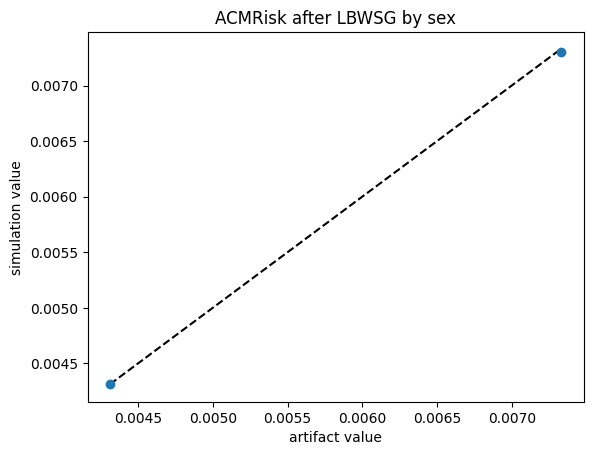

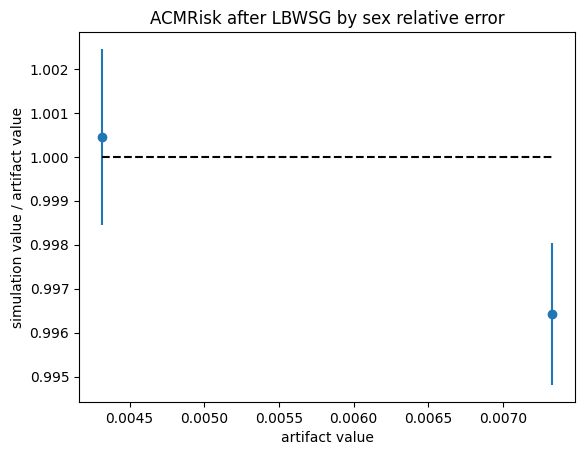

Mutators:


[ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.1.preterm_birth.neonatal_preterm_birth_with_rds.modify_death_in_age_group_probability', component=PretermBirth(neonatal_cause=neonatal_preterm_birth_with_rds)),
 ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.2.preterm_birth.neonatal_preterm_birth_without_rds.modify_death_in_age_group_probability', component=PretermBirth(neonatal_cause=neonatal_preterm_birth_without_rds)),
 ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.3.neonatal_cause.neonatal_sepsis_and_other_neonatal_infections.modify_death_in_age_group_probability', component=NeonatalCause(neonatal_cause=neonatal_sepsis_and_other_neonatal_infections)),
 ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.4.neonatal_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.modify_death_in_age_group_probability', component=NeonatalCause(neonata

After ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.1.preterm_birth.neonatal_preterm_birth_with_rds.modify_death_in_age_group_probability', component=PretermBirth(neonatal_cause=neonatal_preterm_birth_with_rds))
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.004315,0.013887,0.001022,0.001205,0.001710,0.003066,0.583824
Male,2729790.0,0.007292,0.019351,0.001649,0.002192,0.003176,0.005882,0.893898


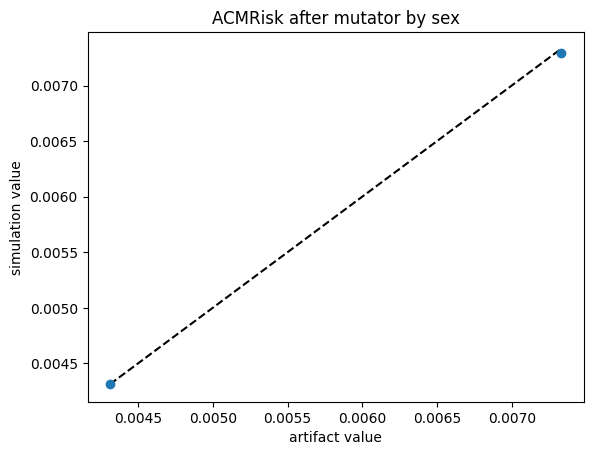

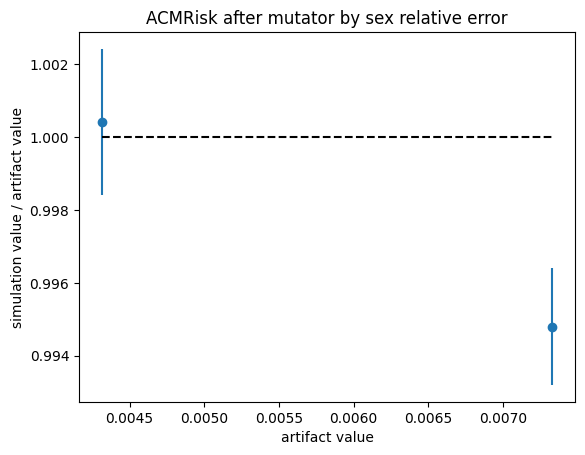

After ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.2.preterm_birth.neonatal_preterm_birth_without_rds.modify_death_in_age_group_probability', component=PretermBirth(neonatal_cause=neonatal_preterm_birth_without_rds))
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.004315,0.013887,0.001022,0.001205,0.001710,0.003066,0.583824
Male,2729790.0,0.007292,0.019351,0.001649,0.002192,0.003176,0.005882,0.893898


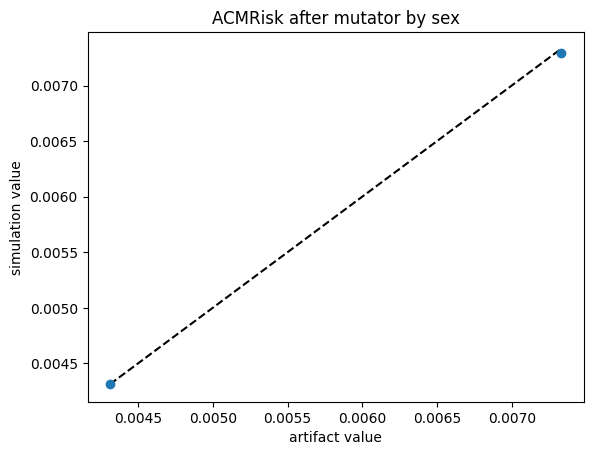

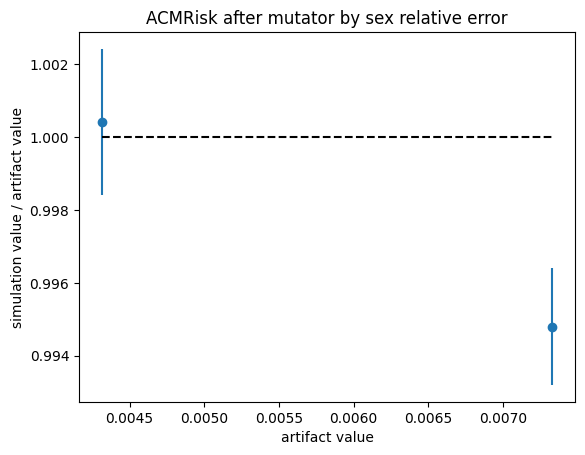

After ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.3.neonatal_cause.neonatal_sepsis_and_other_neonatal_infections.modify_death_in_age_group_probability', component=NeonatalCause(neonatal_cause=neonatal_sepsis_and_other_neonatal_infections))
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.004315,0.013887,0.001013,0.001205,0.001710,0.003066,0.588759
Male,2729790.0,0.007291,0.019343,0.001628,0.002192,0.003176,0.005881,0.904885


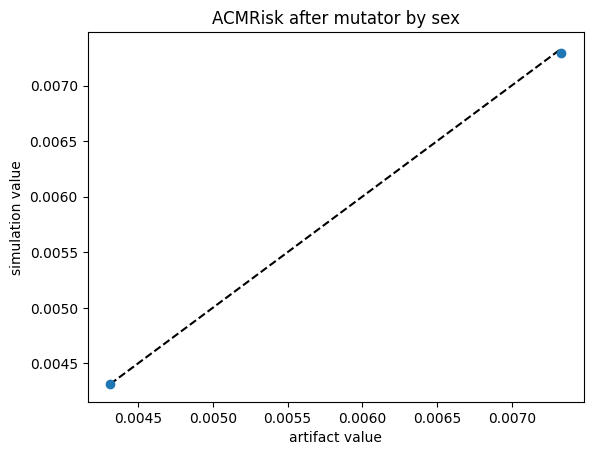

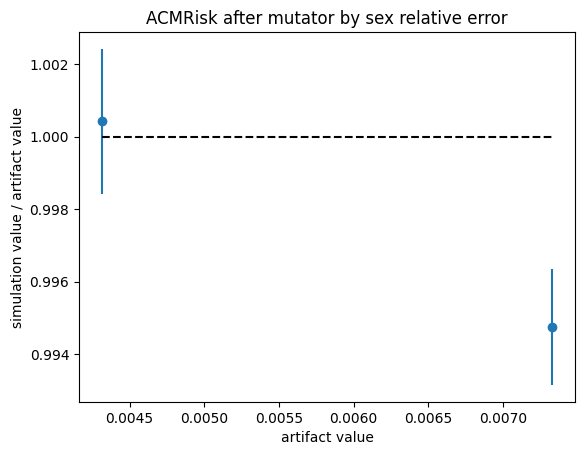

After ValueModifier(resource_type='value_modifier', name='death_in_age_group_probability.4.neonatal_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.modify_death_in_age_group_probability', component=NeonatalCause(neonatal_cause=neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma))
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.004315,0.013887,0.001013,0.001205,0.001710,0.003066,0.588759
Male,2729790.0,0.007291,0.019343,0.001628,0.002192,0.003176,0.005881,0.904885


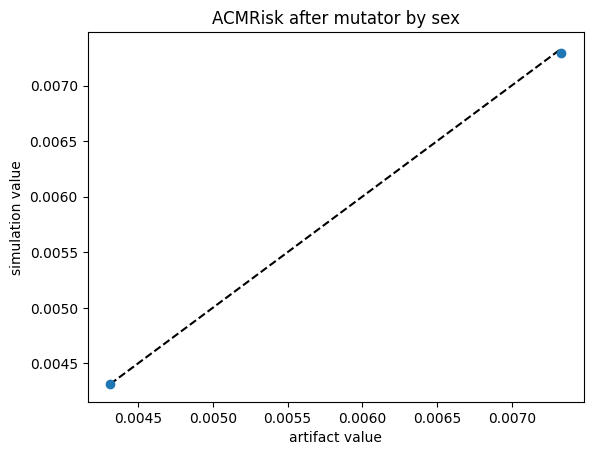

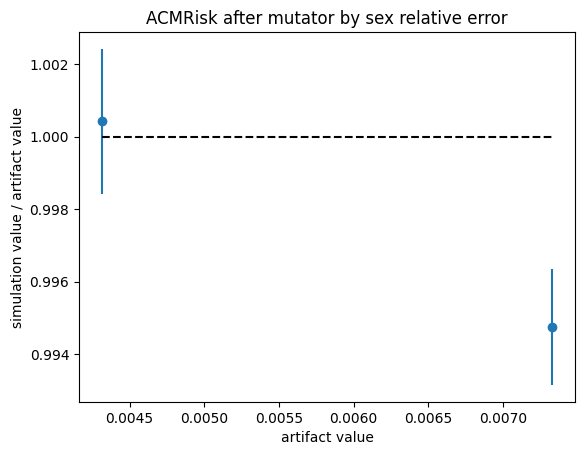

In [81]:
step_by_step_check_acmrisk(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

### Check cause-specific mortality risks

In [82]:
# Check that our transfer above actually worked
assert (
    set(main_sim_components['neonatal_cause.neonatal_sepsis_and_other_neonatal_infections'].lbwsg_acmr_paf(main_sim.get_population().index).unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [83]:
# Check that our transfer above actually worked
assert (
    set(main_sim_components['preterm_birth.neonatal_preterm_birth_with_rds'].lbwsg_acmr_paf(main_sim.get_population().index).unique())
    <=
    set(preterm_csmr_pafs['value'].unique())
)

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Targets


sex_of_child
Female    0.000370
Male      0.001022
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000371,0.001193,0.000088,0.000104,0.000147,0.000263,0.048721
Male,2729790.0,0.001018,0.002722,0.000230,0.000306,0.000443,0.000822,0.119880


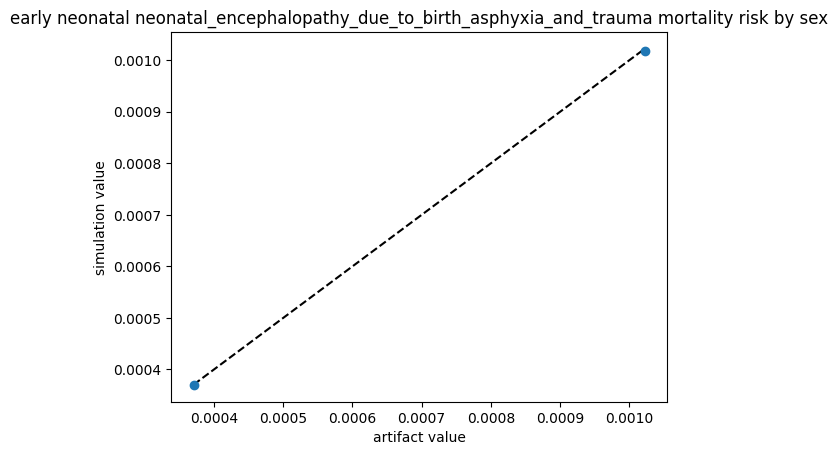

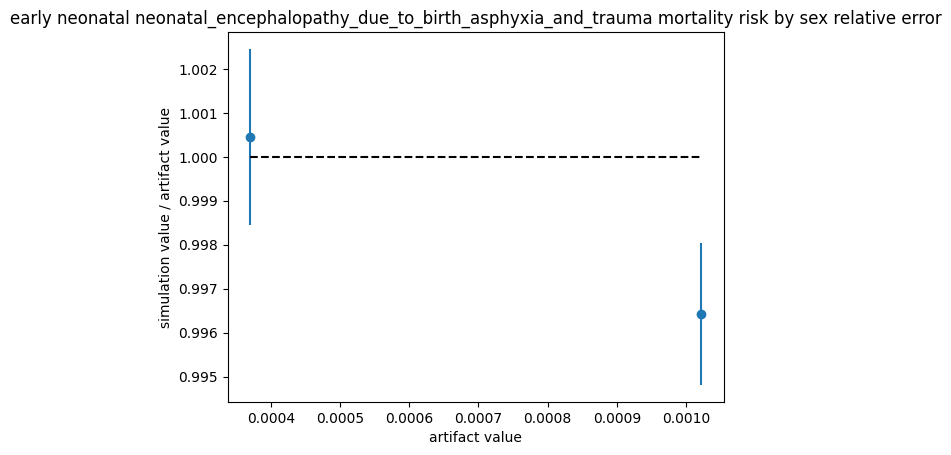

neonatal_sepsis_and_other_neonatal_infections
Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000717,0.002310,0.000161,0.000199,0.000285,0.000509,0.099119
Male,2729790.0,0.001781,0.004759,0.000381,0.000533,0.000776,0.001434,0.220668


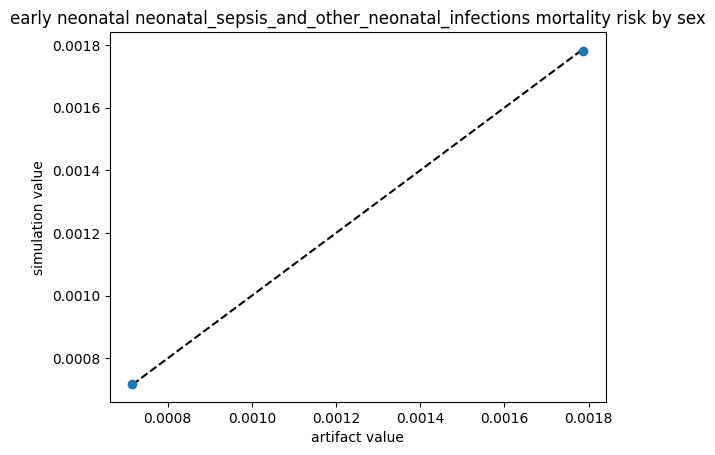

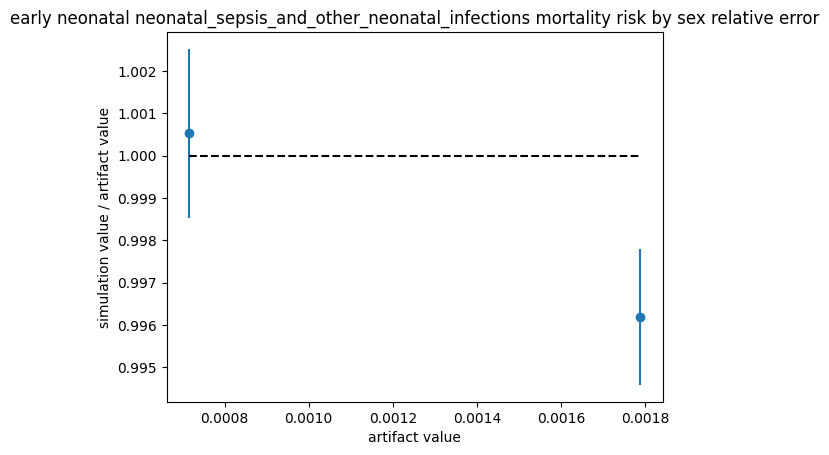

neonatal_preterm_birth
Targets


sex_of_child
Female    0.000492
Male      0.001178
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000492,0.003481,0.0,0.0,0.0,0.0,0.161842
Male,2729790.0,0.001154,0.006415,0.0,0.0,0.0,0.0,0.332593


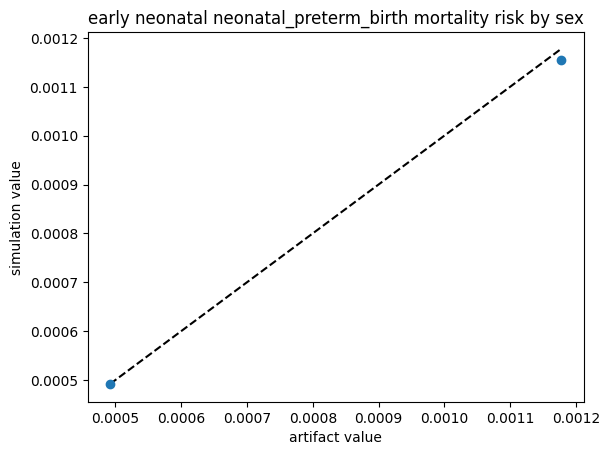

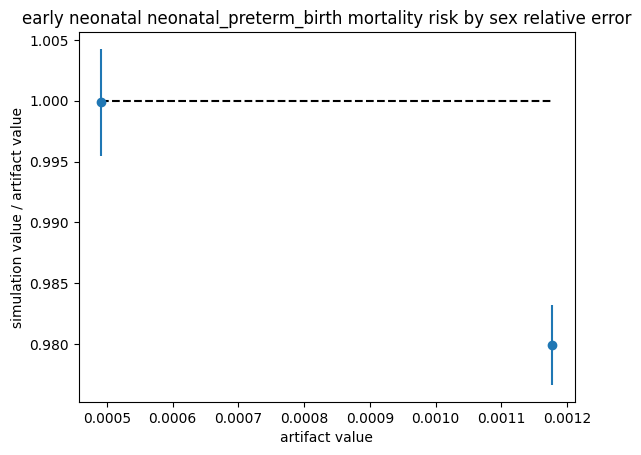

neonatal_preterm_birth_with_rds
Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000418,0.002990,0.0,0.0,0.0,0.0,0.140057
Male,2729790.0,0.000979,0.005496,0.0,0.0,0.0,0.0,0.287824


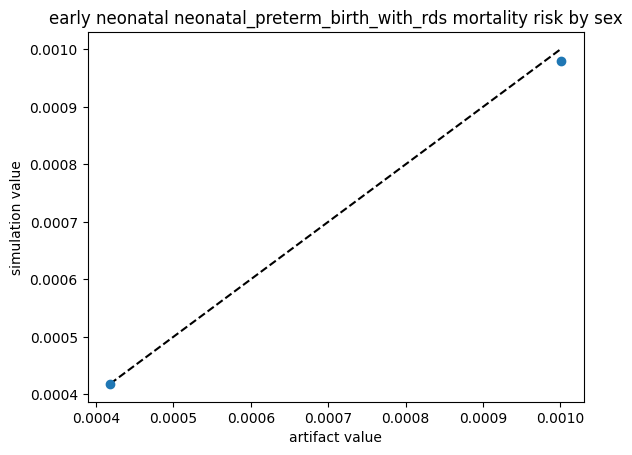

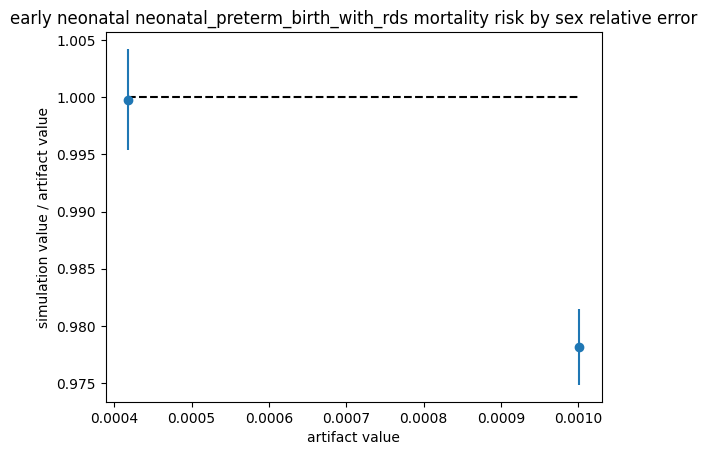

neonatal_preterm_birth_without_rds
Targets


sex_of_child
Female    0.000074
Male      0.000177
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000074,0.000510,0.0,0.0,0.0,0.0,0.021785
Male,2729790.0,0.000175,0.000965,0.0,0.0,0.0,0.0,0.044769


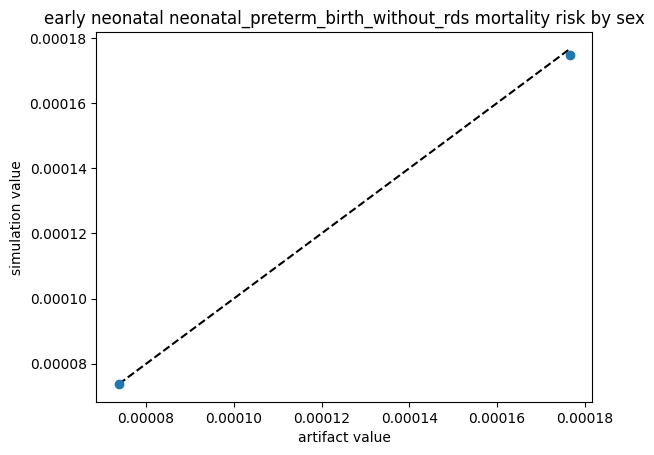

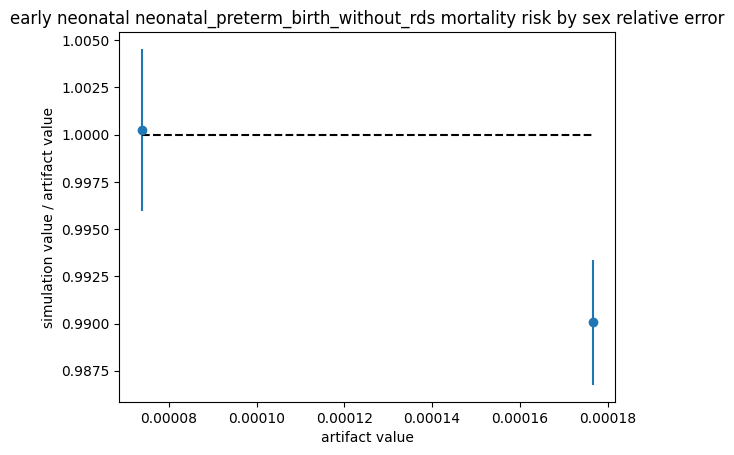

In [84]:
check_csmrisks(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

#### Check frequency of negative other-causes mortality, and impact

This isn't the best check because it is only for a single draw and location. In the one I've chosen, this rarely happens, apparently.

In [85]:
csmrisk_pipeline_names = result = sorted({item for values in CAUSE_NAME_TO_CSMRISK_PIPELINES.values() for item in values})
csmrisk_pipeline_names

['encephalopathy_csmr',
 'preterm_with_rds_csmr',
 'preterm_without_rds_csmr',
 'sepsis_csmr']

In [86]:
total_csmrisk = 0

for pipeline_name in csmrisk_pipeline_names:
    total_csmrisk += (
        getattr(main_sim_components['neonatal_mortality'], pipeline_name)(alive_idx).rename('total_csmrisk')
    )

total_csmrisk

2          0.000343
3          0.000903
4          0.001197
5          0.004780
8          0.007040
             ...   
9999993    0.004974
9999995    0.001005
9999996    0.000849
9999997    0.005050
9999999    0.000440
Name: total_csmrisk, Length: 5329858, dtype: float64

In [87]:
total_csmrisk.describe()

count    5.329858e+06
mean     2.794942e-03
std      1.080174e-02
min      2.486794e-04
25%      4.393585e-04
50%      8.499951e-04
75%      1.839322e-03
max      6.731410e-01
Name: total_csmrisk, dtype: float64

In [93]:
(total_csmrisk > mortality_risk).mean()

0.0

In [94]:
# Expect CSMRisks to be underestimated by this amount as a result
(total_csmrisk - mortality_risk).clip(0).sum() / total_csmrisk.sum()

0.0

#### Check individual steps in calculation of cause-specific mortality risks

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Initial cause-specific mortality risk


sex_of_child
Female    0.000370
Male      0.001022
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000371,0.001193,0.000088,0.000104,0.000147,0.000263,0.048721
Male,2729790.0,0.001018,0.002722,0.000230,0.000306,0.000443,0.000822,0.119880


Targets


sex_of_child
Female    0.000370
Male      0.001022
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000371,0.001193,0.000088,0.000104,0.000147,0.000263,0.048721
Male,2729790.0,0.001018,0.002722,0.000230,0.000306,0.000443,0.000822,0.119880


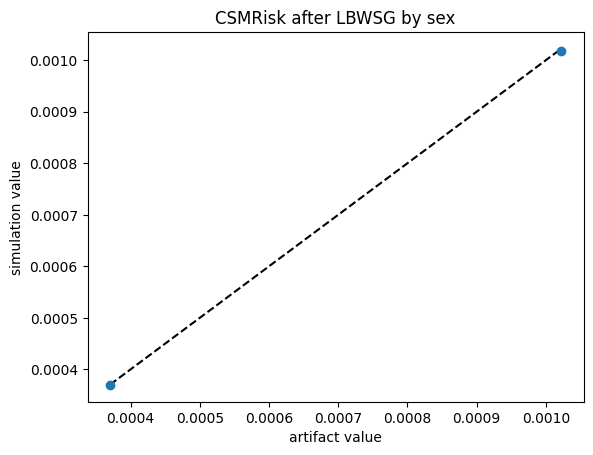

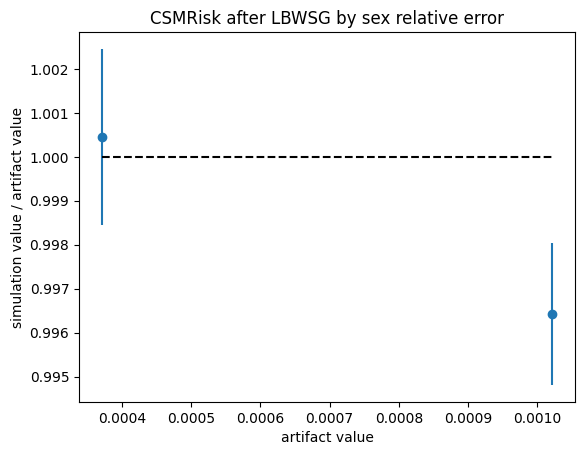

Mutators:


[]

neonatal_sepsis_and_other_neonatal_infections
Initial cause-specific mortality risk


sex_of_child
Female    0.000716
Male      0.001788
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000716,0.002307,0.000170,0.000200,0.000284,0.000509,0.094184
Male,2729790.0,0.001781,0.004761,0.000402,0.000535,0.000776,0.001437,0.209681


Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000716,0.002307,0.000170,0.000200,0.000284,0.000509,0.094184
Male,2729790.0,0.001781,0.004761,0.000402,0.000535,0.000776,0.001437,0.209681


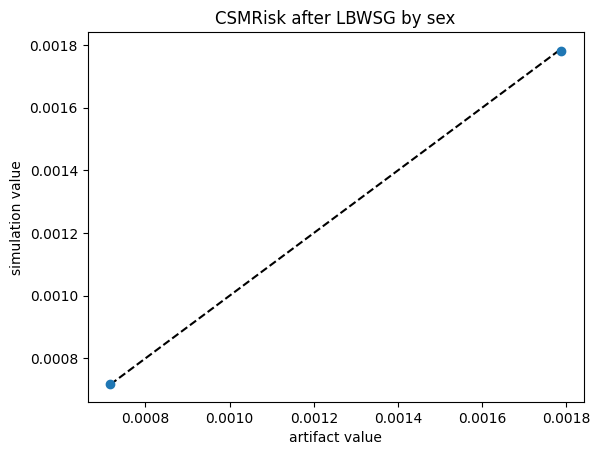

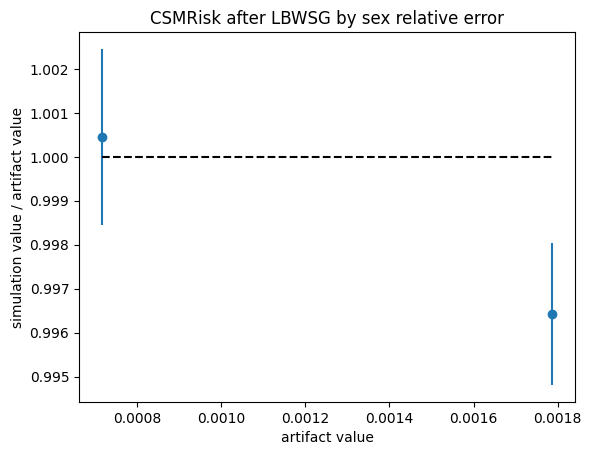

Mutators:


[ValueModifier(resource_type='value_modifier', name='neonatal_sepsis_and_other_neonatal_infections.csmr.1.intervention_risk_effect.antibiotics.modify_target_pipeline', component=InterventionRiskEffect(lack_of_intervention_risk=antibiotics)),
 ValueModifier(resource_type='value_modifier', name='neonatal_sepsis_and_other_neonatal_infections.csmr.2.intervention_risk_effect.probiotics.modify_target_pipeline', component=InterventionRiskEffect(lack_of_intervention_risk=probiotics))]

After ValueModifier(resource_type='value_modifier', name='neonatal_sepsis_and_other_neonatal_infections.csmr.1.intervention_risk_effect.antibiotics.modify_target_pipeline', component=InterventionRiskEffect(lack_of_intervention_risk=antibiotics))
Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000717,0.002310,0.000161,0.000199,0.000285,0.000509,0.099119
Male,2729790.0,0.001781,0.004759,0.000381,0.000533,0.000776,0.001434,0.220668


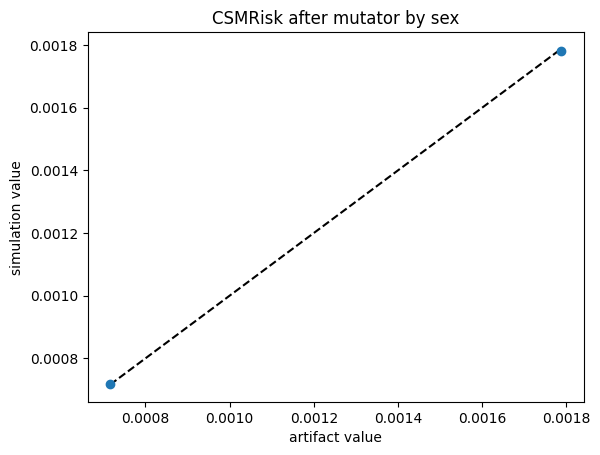

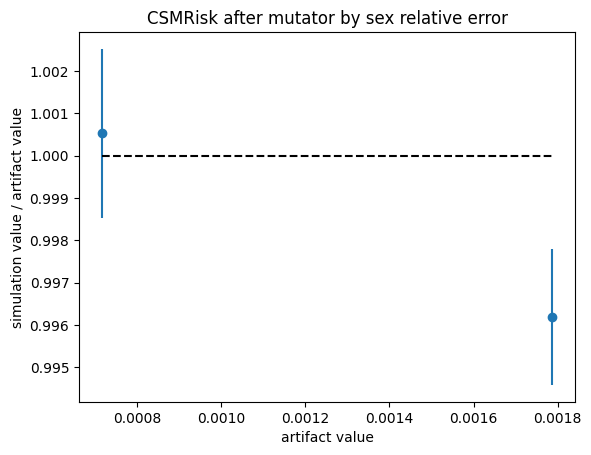

After ValueModifier(resource_type='value_modifier', name='neonatal_sepsis_and_other_neonatal_infections.csmr.2.intervention_risk_effect.probiotics.modify_target_pipeline', component=InterventionRiskEffect(lack_of_intervention_risk=probiotics))
Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000717,0.002310,0.000161,0.000199,0.000285,0.000509,0.099119
Male,2729790.0,0.001781,0.004759,0.000381,0.000533,0.000776,0.001434,0.220668


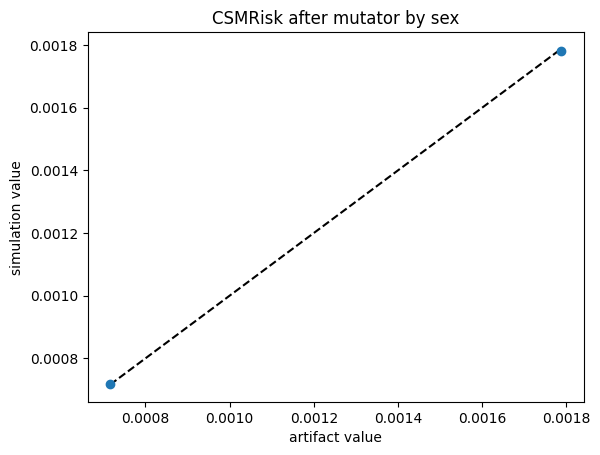

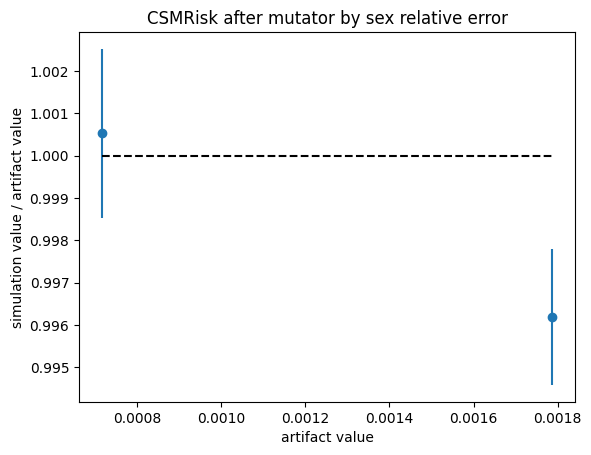

neonatal_preterm_birth_with_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.000492
Male      0.001178
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.133331
Male      0.180029
Name: value, dtype: float64

Targets


sex_of_child
Female    0.000492
Male      0.001178
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000493,0.001255,0.0,0.0,0.0,0.0,0.003690
Male,2729790.0,0.001177,0.002513,0.0,0.0,0.0,0.0,0.006541


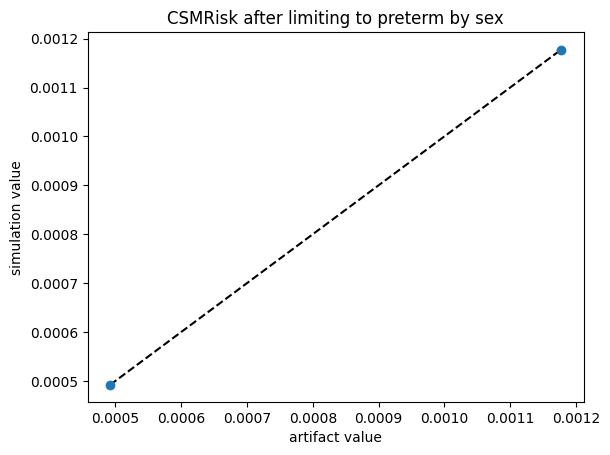

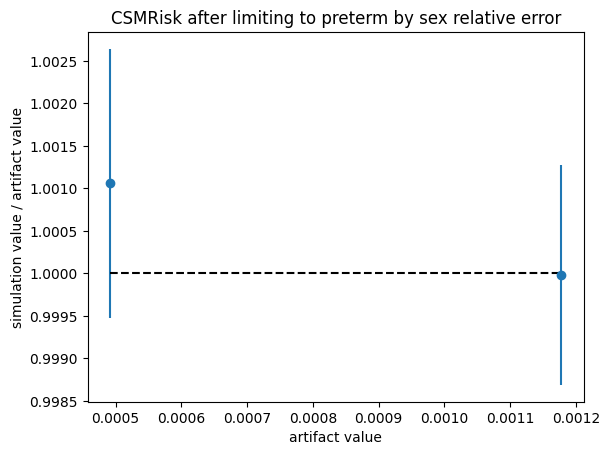

Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000419,0.001067,0.0,0.0,0.0,0.0,0.003137
Male,2729790.0,0.001001,0.002136,0.0,0.0,0.0,0.0,0.005560


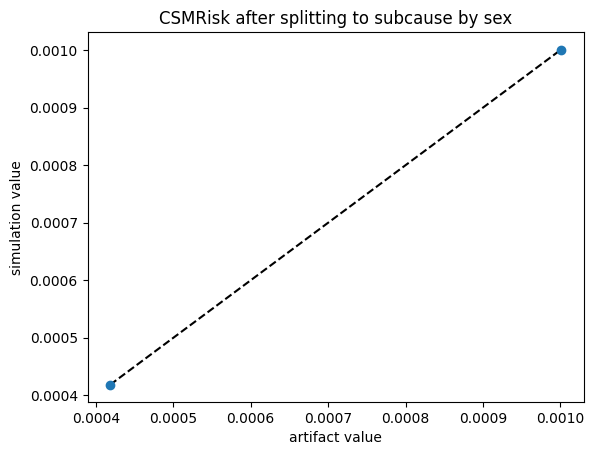

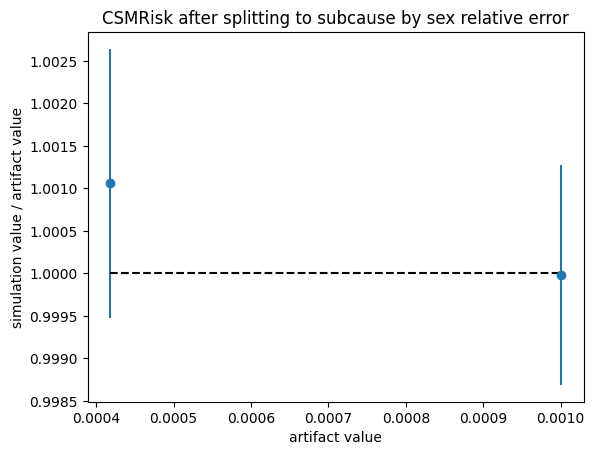

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000418,0.002893,0.0,0.0,0.0,0.0,0.123448
Male,2729790.0,0.000991,0.005466,0.0,0.0,0.0,0.0,0.253692


Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000418,0.002893,0.0,0.0,0.0,0.0,0.123448
Male,2729790.0,0.000991,0.005466,0.0,0.0,0.0,0.0,0.253692


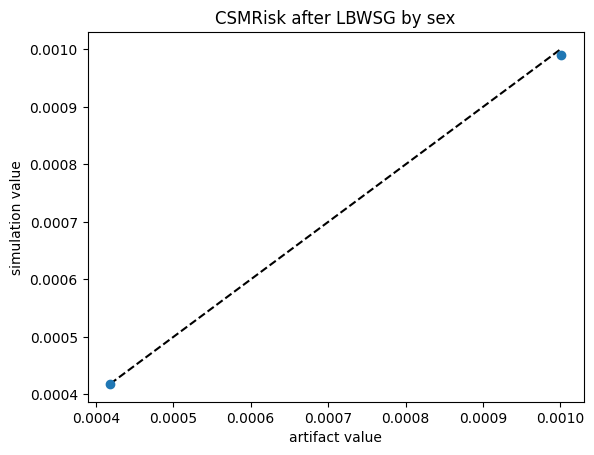

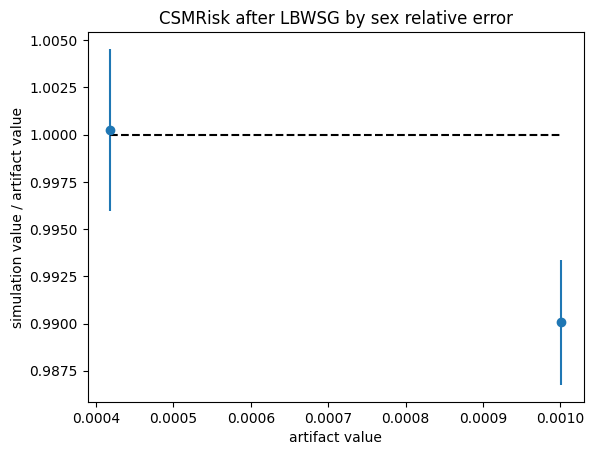

Mutators:


[ValueModifier(resource_type='value_modifier', name='neonatal_preterm_birth_with_rds.csmr.1.cpap_and_acs_risk_effect.modify_target_pipeline', component=CPAPAndACSRiskEffect())]

After ValueModifier(resource_type='value_modifier', name='neonatal_preterm_birth_with_rds.csmr.1.cpap_and_acs_risk_effect.modify_target_pipeline', component=CPAPAndACSRiskEffect())
Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000418,0.002990,0.0,0.0,0.0,0.0,0.140057
Male,2729790.0,0.000979,0.005496,0.0,0.0,0.0,0.0,0.287824


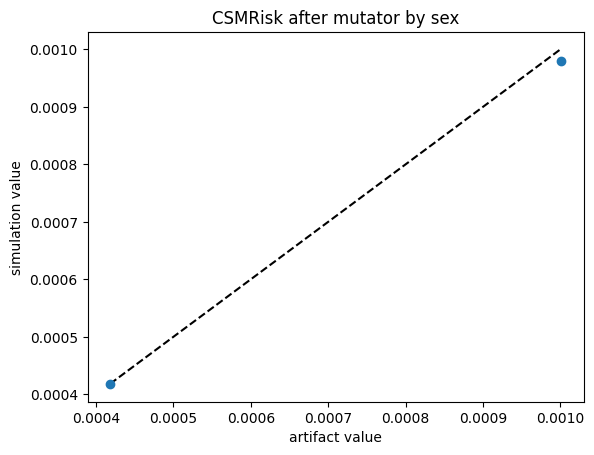

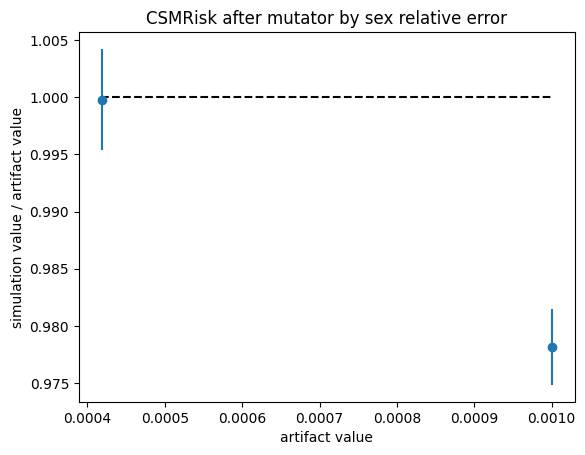

neonatal_preterm_birth_without_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.000492
Male      0.001178
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.133331
Male      0.180029
Name: value, dtype: float64

Targets


sex_of_child
Female    0.000492
Male      0.001178
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000493,0.001255,0.0,0.0,0.0,0.0,0.003690
Male,2729790.0,0.001177,0.002513,0.0,0.0,0.0,0.0,0.006541


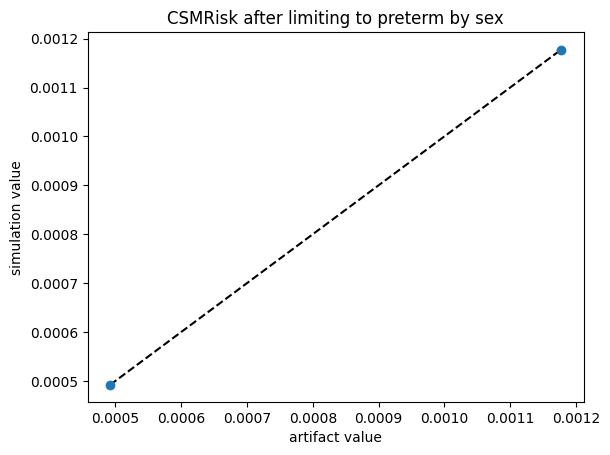

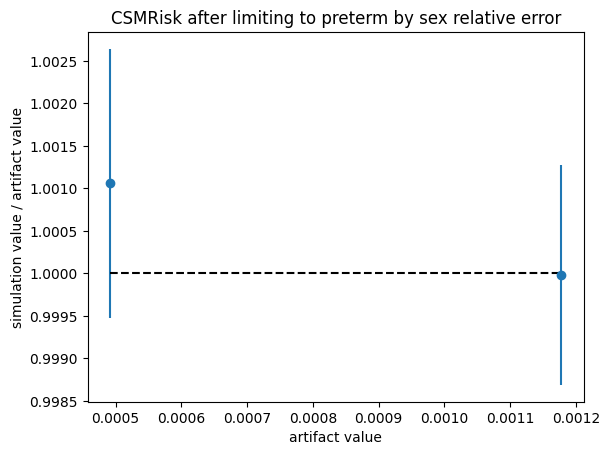

Targets


sex_of_child
Female    0.000074
Male      0.000177
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000074,0.000188,0.0,0.0,0.0,0.0,0.000554
Male,2729790.0,0.000177,0.000377,0.0,0.0,0.0,0.0,0.000981


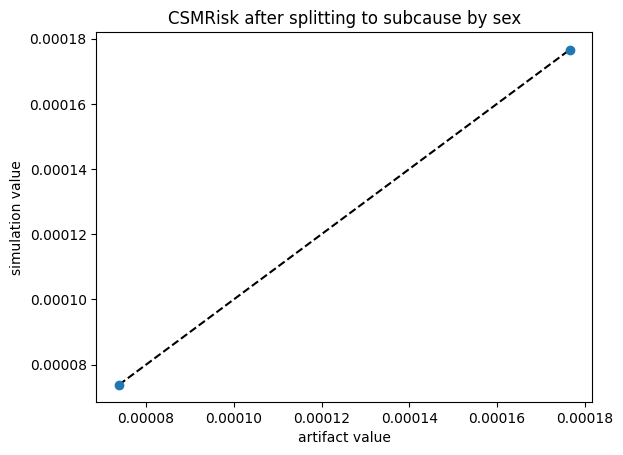

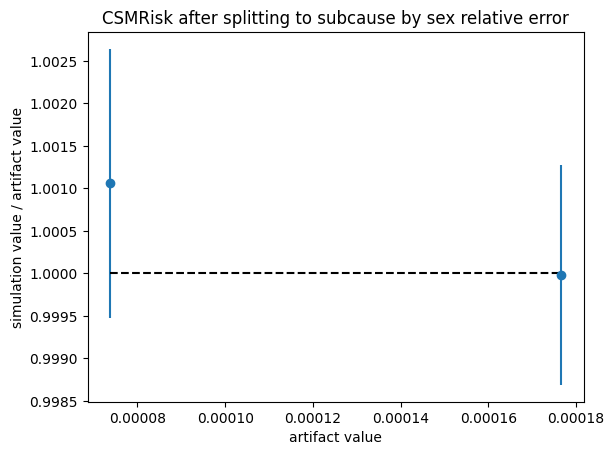

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000074,0.000510,0.0,0.0,0.0,0.0,0.021785
Male,2729790.0,0.000175,0.000965,0.0,0.0,0.0,0.0,0.044769


Targets


sex_of_child
Female    0.000074
Male      0.000177
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2600068.0,0.000074,0.000510,0.0,0.0,0.0,0.0,0.021785
Male,2729790.0,0.000175,0.000965,0.0,0.0,0.0,0.0,0.044769


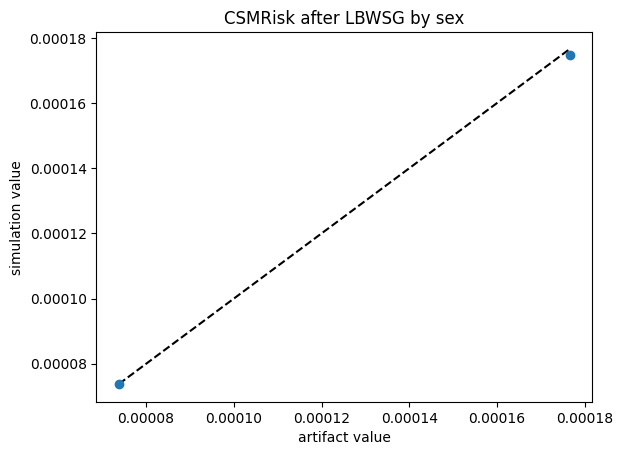

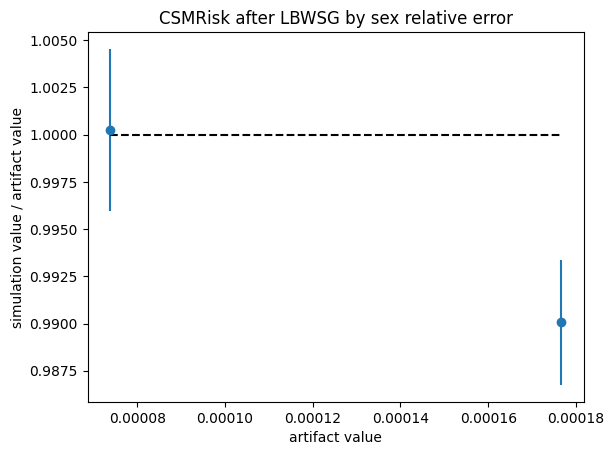

Mutators:


[]

In [90]:
for cause_name in NEONATAL_CAUSES:
    if cause_name == 'neonatal_preterm_birth':
        continue
    print(cause_name)
    step_by_step_check_csmrisk(cause_name, LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

In [91]:
assert not any_failures

In [92]:
!date

Tue Nov  4 09:46:48 PM PST 2025
